# Feature analysis — price momentum (per-exchange drift, short & long)

This notebook is two things at once: a **method** for analysing a trading feature, and a
**worked example** of that method on one feature. The text explains what to do and why; the
code does it.

We build features for a model that forecasts one exchange's mid-price about 100 ms ahead.
Three crypto exchanges appear throughout — **byb** (Bybit), **bin** (Binance), **okx** (OKX) —
and **byb is the target**: the one we predict. ("Mid-price" = the midpoint between the best
buy and best sell quote.) The next section explains the model these features feed.

To analyse a new feature, copy this notebook and change the parts specific to the feature:
**what it is and why** (§1), **its exact definition** (§2), and **its builder** — the
`signed_ret` / momentum functions in §3. The data loading, the checks, and the plots adapt on
their own.

**The example** is `price_momentum`: how strongly a venue's own mid-price has been *trending*
over a recent window, on the trade clock. We build the same momentum atom for **every** venue
(byb's own leg *and* the cross-venue okx/bin legs) and keep them all — momentum on byb is the
direct signal; momentum on okx/bin is a **cross-venue lead** test (does another venue's trend
lead byb's next move?). Three forms are studied, all from one atom `signed_ret_N = EMA(Δlog mid)`:

1. **signed_return_momentum** — the σ-normalised drift `signed_ret_N / (σ_ev·k)`. RAW it is a *level
   scaled by returns*, so we **build it raw, measure its regime-invariance scale (Gate A), and divide
   by `σ_ev` only if it fails** (never assumed).
2. **trend_efficiency_ratio** — `EMA(Δlog mid) / EMA(|Δlog mid|) ∈ [−1,1]` (Kaufman efficiency: net
   move ÷ path length). A **bounded ratio**, invariant **raw**.
3. **momentum_spread** — `signed_ret_fast − signed_ret_slow`, a **trade-clock MACD** (fast trend minus
   slow trend), the freshest-acceleration read.

It is a textbook **price-head (direction)** feature, and we check the rate head too.

**A feature's *analysis* is done when two checks pass:**
- **The parity check (§4)** — a second implementation reproduces the feature on real data, so the code really computes what we think it does.
- **The hygiene gates (§5)** — the signal is real and holds in any market, not just an echo
  of "the market is volatile right now."

Everything after that decides *which part of the model* the feature feeds, and *at what
time-scale* — and the §10 checklist (streaming builder, tests, multi-block OOS) gates **shipping**: analysis-done is not ship-done.

## The model these features feed: two heads

A feature is only worth something if it helps the model predict, so it's worth knowing what
the model does. We forecast how byb's mid-price moves over the next ~100 ms, and we split
that into two simpler questions — the two **heads**:

**Price head — which way and how far?** Over the next few price-moves, what is the *signed*
move (its direction *and* its size, together)? The head predicts the whole distribution of
that move, in units of byb's recent **volatility** — the **volatility yardstick** `σ_ev`
(the exp-weighted RMS of byb's *actual* mid-moves) — so the head's target is
`price change ÷ σ_ev`. **This is `price_momentum`'s home head** — momentum is a directional signal.

**Rate head — how many moves?** Busy markets pack many price-moves into the window, quiet
ones few. This head predicts the *count* of moves over the next 100 ms as a distribution,
measured against the recent pace — the **rate yardstick** `λ_ev` — so its target is
`count ÷ λ_ev`.

**What's a yardstick?** A causal, trailing estimate of byb's *volatility* (`σ_ev`) and move
*rate* (`λ_ev`), from past data only. A regime gauge, nothing more. When a feature *carries* that regime and you want it gone, dividing
by the yardstick is **one option** for removing it (only *when applicable* — you can't always
divide the regime out of a feature). Both are EMAs **decayed on the trade clock** (`α = 2/(span+1)`)
but **updated between trades** — they react to every byb mid-move, so they read live at every
instant. They use one fixed span, `YARDSTICK_N` (any feature may use that span too). (`σ_ev` is
the exp-weighted RMS of byb's *actual* mid-moves — read as an `E/W` ratio so the many non-move
trades cancel out; `λ_ev` is a ratio of two EMAs — the exp-weighted byb move-count `W` (the same
`W` that is `σ_ev`'s denominator) ÷ the exp-weighted seconds-per-trade = byb's moves per second.) Like every average here, they live
on the trade-tick clock — never wall-clock or a hard window.

**Why split into two heads?** A move over a window is just *how many* little moves happen
times *how big* each one is. Pulling "how many" (rate) apart from "how big" (price) lets each
head learn a steadier thing — and is why there are two yardsticks, one per head.

**Putting them back together.** The price head isn't a single distribution — it's a *family*,
one per possible move-count: "if `k` moves happen, here's the spread of the total price
change" (call it `D_k`). The rate head gives the probability of each count, `P(K = k)`. The
100 ms move is the two **mixed** — for every count `k`, take the price head's `k`-move
distribution, weight it by the rate head's probability of exactly `k` moves, and sum:

`distribution of the 100 ms move  =  Σ_k  P(K = k) · D_k`

More moves → a wider spread, so the rate head's "how many" sets the scale and the price head's
`D_k` sets the shape. This is why a feature that predicts the *count* (rate head) and one that
predicts the *per-move direction* (price head) are both useful: they feed the two factors that
multiply together.

**Backed by research.** This "how many × how big" split is the classic **subordination** model
of asset prices (Clark, 1973, *Econometrica*; Ané & Geman, 2000, *Journal of Finance*): returns
over a fixed clock-time window look messy, but become well-behaved once you condition on the
*number* of events. So modelling the event count and the per-event move separately, then mixing
them, is a principled decomposition — not just a convenient one.

Every feature here feeds one or both heads, and borrows the matching yardstick when it needs
to be made comparable across markets. Two questions recur below: does a feature's *signed*
value predict the move (price head), and does its *magnitude* predict how many moves come
(rate head)? Those are diagnostics — the model is fed the **signed** feature for *both* heads,
and the rate head learns the magnitude (and how features cancel or reinforce) on its own. And they
are **marginal screens** — does the feature carry signal worth feeding — **not** measures of
distributional fit: the model's actual targets are the count distribution `P(K = k)` and the
count-conditioned price family `D_k` mixed above, fit downstream, not what these rank-ICs measure
(§7 inspects the realised count/return distributions by feature bucket).

## Guard rails — do this, not that

Hard rules, learned the hard way. Follow them unless you have a specific, written reason not to.

**Don't**
- **Don't assume a fixed leader.** No exchange always leads — leadership moves around. Build
  the feature the same way for every exchange and keep them all. `price_momentum` is built per
  venue (each off its *own* mid-moves) for exactly this reason.
- **Don't pick "the best exchange"** by average score — that throws away the moments another
  exchange leads (often the most informative ones). Keep all; let the model weight them.
- **Don't pool exchanges by default.** Pooling can blur the cross-exchange structure. For a
  poolable feature (this one *is* poolable — a per-exchange number, not a gap *between*
  exchanges), first check per-exchange vs single vs pooled across time-scales (§9).
- **Don't normalize reflexively.** Divide volatility or rate out of a feature *only when it
  needs it* — a ratio or imbalance is already comparable across markets. (The efficiency ratio is
  bounded and needs none; the signed-drift level is **measured** by Gate A and normalised only if it fails.)
- **Don't invent your own vol/rate scale.** When you do normalize, use the model's yardstick
  (`σ_ev` or `λ_ev`), so the feature shares units with the target.
- **Don't trust a correlation** until it survives the regime controls (rate and vol) — else
  it may just be re-reporting "the market is volatile."
- **Don't ship a feature without the §4 parity check** — a second, production-style build reproducing it on real data.
- **Don't hand-roll a streaming EMA, and don't use `EventEMA` — use only `KernelMeanEMA` or `LiveFrontEMA`.**
  Every *online* average — the §4 production/streaming parity build, and any event-by-event EMA state anywhere
  in the notebook — MUST be exactly one of **two** `boba.ema` classes: **`KernelMeanEMA`** (the self-normalising
  `E / W` read — for a **flow**) or **`LiveFrontEMA`** (the live-front read — for a **level**). Both expose
  **separate `tick()` (decay) and `add()` (inject)** calls — that separation is the whole point: decay rides the
  shared trade clock (once per trade-timestamp) while injection rides each relevant-event timestamp, and the two
  must fire **independently** (see the inject-≠-decay rule below). **Never use `EventEMA`:** its single `step()`
  **couples decay and injection** into one call, so it *cannot* decay on the trade clock while injecting on a
  different event stream — that directly violates the inject-once / decay-once-independently rule. And **never**
  hand-roll a scalar EMA (no private `_ScalarEMA`, no `(1−α)·s + α·x` per-event loop) or reach for
  `scipy.signal.lfilter` in the streaming build. Every quantity here is either a **flow** (→ `KernelMeanEMA`) or
  a **level** (→ `LiveFrontEMA`); if you think you need anything else, you've mis-modelled it (a slope/covariance
  is a ratio of flow EMAs — several `KernelMeanEMA`s, not a bespoke class). §4 exists to validate the **actual
  production code** (`boba.ema` online vs §3's vectorized path), not a throwaway re-implementation that could
  carry the same blind spot. (The §3 *vectorized* analysis may still use `lfilter` — the offline array path, not
  online EMA state.)
- **Don't peek ahead.** Every value uses only data at-or-before its own timestamp.
- **NEVER a hard / boxcar / rolling window.** No rolling max/min (Donchian), no fixed-N lookback
  buffer. A "range" / "breakout" must be **EMA-based**. Every momentum atom here is a
  **trade-clock EMA of the log-return**, O(1) state, never a window.
- **Don't over-transform for the network.** Pick the lightest reshaping that works.

**Do**
- **Do start with a falsifiable hypothesis** — a mechanism for why it should work, and what
  would prove it wrong.
- **Do make every average a trade-tick EMA.** *Every* smoother in the pipeline — the momentum
  legs, `σ_ev`, `λ_ev`, any rolling statistic — is an exponential moving average
  **decayed once per tick of the one shared trade clock** (one tick per trade-timestamp across **all** venues; simultaneous prints count once; `α = 2/(span+1)`) yet **taking in a fresh value at most once per timestamp that carries a relevant event** (a venue mid-move — same-timestamp events as one update, never stale between trades), **never** a wall-clock
  average and **never** a hard/boxcar window. That keeps the whole state **O(1)** (one scalar
  per average, no ring buffers) and bit-identical online vs offline. Establish and validate the
  convention against a plain one-event-at-a-time loop on a real block — exactly as
  `notebooks/03_ema_clock_validation.ipynb` does, and as the §4 parity check re-checks here.
- **Do make every EMA react to relevant events as they land — never let it read a stale state.** An EMA's
  *decay* lives on the trade clock, but it must *update its value* at **each timestamp that carries a
  relevant event** (same-timestamp events aggregated to one update). For a momentum leg, that relevant event
  is its venue's mid-*move*: it injects each fresh `Δlog mid` the instant it lands. A value that ignores the
  moves since the last clock read is **stale** — wrong, and a silent source of lag. The choice of EMA *and
  when it updates* is what makes the read well-behaved — pick both deliberately (see "Choosing the EMA").
- **Do inject at most one EMA sample per timestamp, and decay once per shared-trade-clock tick — this
  never changes.** At each timestamp an EMA injects **one** sample *iff* a relevant event for that EMA
  lands there: for a momentum leg, a venue mid-move; for `σ_ev`, a byb mid-move. A timestamp with only
  **irrelevant** trades injects nothing for that EMA, yet it still
  **ticks** (decays) once *iff* a trade lands, on the one **shared** trade clock
  (one tick per trade-timestamp across **all** venues, simultaneous prints counting once). Inject and
  decay are independent and neither ever fires more than once per timestamp, whatever the feature.
  Records sharing a timestamp are **one** sample, not a sequence: same-timestamp aggregation sets only
  that sample's **value** — never the number of samples, never the number of ticks. A venue's momentum sums
  signed mid-*moves*, so collapsing N simultaneous mid records to the *final* mid (one Δlog) is what keeps the
  sum honest — treating them as a sequence would fabricate N−1 phantom intra-instant round-trips.
- **Do always read the *freshest* value — never freeze on the last trade's.** An EMA decays once
  per trade-timestamp (that fixes its memory in trade-count), but its *read* must use the latest
  mid-move: fold in the partial epoch of moves since the last trade — never the stale snapshot frozen
  at the last trade tick. Keep the two clocks separate: refresh the *read* on every move, but keep the
  *decay/weighting* on the trade clock. (Fresh costs nothing for a 100 ms target and never lags; stale
  silently lags when trades are sparse.)
- **Do test against both heads — but feed both the *signed* feature.** Check whether the
  signed feature predicts *direction* (price head — momentum's home) and whether its *magnitude*
  predicts *intensity* (rate head). Those are diagnostics — in the model, feed the **signed**
  feature to *both* heads, never a pre-computed `|feature|`. The rate head learns the magnitude
  itself, *and* learns that a +trend on one venue can cancel a −trend on another.
- **Do score out-of-sample** with a purged, embargoed walk-forward (strictly past→future) — a single split is only a faster screen.
- **Do use the freshest valid price per exchange.**
- **Do treat a feature as a family across time-scales** and let the data assign scales to heads.
- **Do prove regime-invariance with Gate A — never assume it.** A usable feature reads the *same* in calm and
  wild markets: its distribution must be **stable against the regime diagnostics we track** (not a proof of independence). Gate A's **control-free** checks (§6):
  **scale** (std stable across vol buckets, max/min < ~3); and — for **both the signed feature and its
  magnitude `|feature|`** (the rate head sees the signed feature but can learn its magnitude) — that it does **not track** the regime
  (`|IC(·, vol & rate level)| ≈ 0`, the monotone test) **nor leak non-monotonically** (per-decile-mean
  **dispersion** small, which catches a U-shaped leak the monotone IC misses). All are **hard** gates. A raw
  **level** (`σ_ev`, `λ_ev`, a σ-scaled drift) usually *is* the regime and fails them — but *measure, don't
  assume*: a **ratio / bounded / normalised** form may pass (the efficiency ratio is exactly such a bounded ratio), and even a ratio of two non-invariant levels can
  be invariant when they co-move. Never call a feature regime-invariant *or* not — nor a level useless — until
  **every** Gate A number says so. (Corollary: don't assert *any* property — invariance, a lead/lag, "it's
  circular" — you haven't measured on a real block.)
- **Don't fuse the two gates — they're independent.** *Regime invariance* (Gate A) is the feature's own
  distribution being stable across regimes; *signal* (Gate B) is what it predicts over the **invariant**
  controls. The raw vol/rate **levels aren't Gate-B controls** (they aren't valid alpha features) — putting them in
  the signal test just smuggles the Gate-A regime test back in; they serve only as the Gate-A regime *coordinate*. And **a control can be a valid feature**: when the
  feature under test *is* a regime descriptor, marginal-over-its-own-controls is circular — judge it on its
  **standalone** signal, and never call it "redundant" from its algebra alone.

## 1. What the feature is, and why it might work

Every feature starts with a one-line summary and a **hypothesis you could be wrong about**.
If there's no story for *why* it should predict anything, don't bother testing it.

| | |
|---|---|
| **what** | how strongly each venue's own mid has been *trending* recently (its drift), short & long scale |
| **feeds** | both heads — but **price head (direction) is home**: momentum is a directional signal. Rate head (intensity) is a diagnostic. Both are fed the *signed* feature |
| **predicts** | byb's mid-price 100 ms from now |

**The idea.** Take a venue's log mid-price increments `Δlog mid` and smooth them on the trade clock:
`signed_ret_N = EMA(Δlog mid, N)` is the recent **signed drift** — positive when the venue has been
climbing, negative when falling. Three reads of it:
- divide by `σ_ev` → **signed_return_momentum**, the drift in volatility units;
- divide by `EMA(|Δlog mid|, N)` → **trend_efficiency_ratio** ∈ [−1,1], how *straight* the path was
  (Kaufman's efficiency ratio: net move ÷ total distance travelled — 1 = a clean trend, 0 = chop);
- subtract a slower drift → **momentum_spread** = `signed_ret_fast − signed_ret_slow`, a MACD that
  fires when the trend *accelerates*.

**Why it should work.** Order flow arrives in bursts and prices have short-horizon
**autocorrelation** (continuation): a venue that has just ticked up tends to tick up again over the
next few moves, as a large order keeps sweeping or informed flow keeps pushing one side. So a venue's
recent drift predicts a little more of the same — *continuation* (positive IC). The opposite,
**mean-reversion** (a stretched move snaps back, negative IC), is equally plausible at these horizons —
which way it goes, and at which scale, is precisely what we measure. For the **cross-venue** legs the
mechanism is a **lead/lag**: if okx/bin trends a beat before byb, their momentum predicts byb's
catch-up. (We don't pin the exact lag here; "a beat" is roughly tens of milliseconds.)

**What would disprove it.** No predictive power at any time-scale for any venue, or power that is
purely the move *already underway* at the anchor (a contemporaneous echo — netted out in the
echo-netting check), or power that vanishes once we control for the volatility/rate regime.

> **No fixed leader.** It's tempting to call one venue "the leader." Don't — leadership moves around.
> Build the feature *the same way for every venue and keep them all*; the cross-venue legs are tested
> honestly in §6/§9, never assumed to lead.

## Choosing the EMA

Every smoother here is an EMA on the **trade clock**: its **decay** steps once per *trade-timestamp*
(`α = 2/(span+1)`), but its **value updates at most once per timestamp that carries the EMA's own
relevant event** (same-timestamp events as one update). A momentum leg's relevant event is its venue's
mid-*move*; choose the EMA type and injection rule for the statistic being measured.

**Choice 1 — which EMA, and how you read it** (`boba.ema`):

- A **smoothed flow of increments** — `signed_ret_N` is the trade-weighted decayed **sum** of `Δlog mid`
  (a velocity), present only on mid-moves and read with a **live front** that folds in the moves since the
  last trade. So each momentum leg is a decayed-sum EMA: inject `α·Δlog` on each mid-move, decay by
  `(1−α)` on each trade tick, read `committed + α·(increments since the last trade)`. `abs_ret_N` is the
  identical machine fed `|Δlog mid|` — **same events, same weights** — which is what makes the efficiency
  ratio `signed/abs` provably bounded in `[−1,1]`.
- A **sparse flow read as a per-event mean** — `σ_ev` is a *different* shape: a self-normalising
  **`KernelMeanEMA`** `E/W` of byb's squared moves (we want a per-move RMS, not a sum). The momentum legs
  read the running `E` (the decayed sum) directly; `σ_ev` divides by `W`.

**Choice 2 — *when* you push a value in** (the injection clock — a *separate* decision from the decay
clock). Decay is always once per trade-timestamp; the **injection** is once per **real mid-move**, skipping
the many non-move trades. The allowed patterns are:

| pattern | what it weights / measures | use for |
|---|---|---|
| only on the feature's real event, skip irrelevant clock ticks | a **per-real-event sum / mean** | a flow (a momentum leg: push `Δlog` only on a venue mid-move; `σ_ev`: push `r²` only on a byb move) |
| commit every trade-timestamp; read refreshes each book-update timestamp | by **trade-dwell** — a value spanning more trades counts more | a level (gap, price) — not used here |

Classify the timestamp for the EMA being updated. A momentum leg injects **only on a real mid-move of its
own venue** — never on a non-move trade or a book update. Decay rides the shared trade clock (every
trade-timestamp, any venue); injection rides *this venue's* mid-moves.

Between trades:

- **React to every mid-move, and read the freshest value.** Decay rides the trade clock, but the leg must
  *update* on every mid-move and the read must fold the moves since the last trade — never a stale snapshot.
- **Records sharing a timestamp are ONE update** — collapse same-timestamp mid updates to the final mid
  (one move), apply them, then register a single refresh and at most one decay. Treating them as a sequence
  fabricates intra-instant round-trips that never happened in time. (The §4 parity check enforces both.)

## 2. The exact definition

A definition has to get three things right.

**Causal** — it uses only data up to the moment it's computed; no peeking at the future. (A stray
forward-fill is the usual way to break this by accident.)

**Measured on the trade clock** — markets alternate busy and quiet, so we count progress in *trades*
(one tick per trade-timestamp on any exchange — simultaneous prints are one tick) rather than in
clock-seconds. Mid updates between trades refresh what the EMA *reads*, but they do **not** advance
the clock — only a trade does, decaying each EMA once. **Never a hard window** — no rolling max/min, no
fixed-N buffer; the "lookback" is the EMA's span `N`, an exponential memory, not a boxcar.

**Comparable across calm and wild markets** — *measured, not assumed*. The three forms differ exactly
here, which is the heart of the RAW-FIRST rule:

**2a — The atom and the three forms** (one line each):

- atom: `signed_ret_N(ex) = EMA(Δlog mid, N)` — a venue's smoothed signed drift (a velocity).
  `abs_ret_N(ex) = EMA(|Δlog mid|, N)` — its path length (same events/weights).
- **(1) signed_return_momentum = `signed_ret_N / (σ_ev · k)`** — drift in volatility units. RAW, the
  bare `signed_ret_N` is a *level scaled by returns* (bigger in volatile markets), so it is the form we
  **suspect** is non-invariant. We **build it raw, MEASURE its scale across vol buckets (Gate A, §6), and
  divide by `σ_ev` ONLY if it fails** — never assumed. (`k` is a fixed constant — it drops out of every
  rank correlation — so the decision is purely "raw vs `/σ_ev`".)
- **(2) trend_efficiency_ratio = `signed_ret_N / abs_ret_N` ∈ [−1,1]** — Kaufman's efficiency ratio:
  net move ÷ path length. A **bounded ratio**, regime-invariant **raw** (no division needed) — we
  *measure* that too, but the prior is strong.
- **(3) momentum_spread = `signed_ret_fast − signed_ret_slow`** — a trade-clock MACD. A difference of
  two σ-scaled-ish drifts.

**2b — The EMAs we use, and how they update** (applying the two choices above):

- **Each momentum leg** (`signed_ret_N`, `abs_ret_N`) is a **decayed-sum EMA on the trade clock**:
  inject `α·Δlog` (or `α·|Δlog|`) on every venue mid-move, decay by `(1−α)` on each trade tick, and read
  the **live front** `committed + α·(increments since the last trade)`. `N = 1` sets `α = 1` (the leg
  collapses to the freshest increment, no smoothing). `signed_ret_N` and `abs_ret_N` share the move
  detection and weights, so `|signed_ret_N| ≤ abs_ret_N` always → the ratio lives in `[−1,1]`.
- **`σ_ev` and `λ_ev`** (the yardsticks) are a **sparse flow** read as `E/W`: push `byb_return²` on a
  real byb mid-move, decay every trade, read `σ_ev = √(E/W)` = RMS move *per move*. Dividing by `W`
  removes the move *rate* and a fresh EMA's start-up bias, leaving a per-move volatility comparable in
  calm and busy markets. (`λ_ev` is the same move-count `W` divided by an EMA of seconds-per-trade.)

Both reads obey the two between-trade rules. §3 builds exactly this **per venue**; §4 rebuilds it from
raw events with the production streaming state machine (the tested `boba.ema` classes) and confirms the two
paths agree **to floating-point precision** for every venue.

The cell below loads the data, builds the shared trade clock, each venue's mid-move stream (the sparse
flow the momentum legs are built from), and **both byb yardsticks** as `E/W` flows on that clock, span
`YARDSTICK_N`.

In [1]:
import numpy as np, polars as pl
import matplotlib.pyplot as plt
from scipy.signal import lfilter
from scipy.stats import spearmanr
from boba.io import list_blocks, load_block

COIN        = "eth_usdt_p"
TARGET      = "byb_eth_usdt_p"                    # the exchange we predict
EXCHANGES   = ["byb", "okx", "bin"]              # price_momentum is built per venue (each off its OWN mid-moves); keep ALL (no fixed leader)
OTHERS      = ["okx", "bin"]                     # the cross-venue legs (each predicting byb) — byb's own leg is the direct signal
# freshest mid per exchange. front_levels = raw best-bid/ask snapshots; merged_levels = those snapshots fused
# with trades for a fresher mid. byb/okx use merged_levels; bin MUST use front_levels — merged_levels is DISALLOWED for
# bin perp in boba.io (it raises). This is a policy, not a tuning choice.
MID_STREAM  = {"bin": "front_levels", "byb": "merged_levels", "okx": "merged_levels"}
FAST        = [1, 10, 50, 200]                   # fast-EMA momentum spans to sweep (1 = no smoothing, the freshest increment)
SLOW        = [100, 500, 2000, 8000]             # slow-EMA momentum spans (each must exceed the fast one)
SPANS       = sorted(set(FAST) | set(SLOW))      # the single-span family for forms (1) and (2)
HORIZON_NS  = 100 * 1_000_000                    # how far ahead we predict (100 ms, in nanoseconds)
YARDSTICK_N = 10000                              # the ONE span for BOTH byb yardsticks (σ_ev, λ_ev): a trade-tick EMA (α=2/(N+1)) — fixed, used for every feature
block       = list_blocks(TARGET, "front_levels")[0]   # one ~24h slice of recorded data

# load each exchange's mid-price stream (rows already arrive in time order)
def load_mid(ex):
    df = (load_block(block, f"{ex}_{COIN}", MID_STREAM[ex]).select("rx_time", "bid_prc", "ask_prc").drop_nulls())
    return df["rx_time"].cast(pl.Int64).to_numpy(), (df["bid_prc"].to_numpy() + df["ask_prc"].to_numpy()) / 2
mids = {ex: load_mid(ex) for ex in EXCHANGES}

# the shared trade clock: one tick per trade-TIMESTAMP across ALL venues. Simultaneous prints (one order sweeping levels) are ONE event -> ONE tick.
trade_ts = []
for ex in EXCHANGES:
    td = (load_block(block, f"{ex}_{COIN}", "trade").select("rx_time", "prc", "qty")
          .filter((pl.col("prc") > 0) & (pl.col("qty") > 0)))         # drop bad prc=qty=0 prints
    trade_ts.append(td["rx_time"].cast(pl.Int64).to_numpy())
trade_prints = np.concatenate(trade_ts)
merged_ts = np.unique(trade_prints)                               # collapse same-timestamp prints: at most one decay per timestamp
n_ticks = len(merged_ts)
print(f"shared trade clock: {n_ticks:,} ticks (timestamps) from {len(trade_prints):,} trade prints")

# --- per-venue mid-move stream: the sparse flow EACH venue's momentum legs are built from ---
def move_stream(ex):                                                              # build THIS venue's Δlog flow (+ for byb the r^2 / count)
    rx0, mid0 = mids[ex]
    keep = np.concatenate([rx0[1:] != rx0[:-1], [True]])                         # collapse same-TIMESTAMP rows to ONE update (the final mid): simultaneous events are not a sequence
    rx, mid = rx0[keep], mid0[keep]
    lm = np.log(mid)
    dlr = np.empty_like(lm); dlr[0] = 0.0; dlr[1:] = np.diff(lm)                  # Δlog mid per timestamp (signed increment)
    mv = dlr != 0.0                                                              # a REAL mid-move: ONE per timestamp where the mid changed
    return rx[mv], dlr[mv], rx, mid, np.concatenate([[0.0], np.cumsum(mv.astype(float))])
MV = {}                                                                          # ex -> (move_rx, move_dlog, collapsed_rx, collapsed_mid, cum_moves)
for ex in EXCHANGES:
    MV[ex] = move_stream(ex)
byb_rx, byb_mid, cum_mv = MV["byb"][2], MV["byb"][3], MV["byb"][4]               # byb's collapsed mid + running move count (rate-head target)

byb_dt = np.zeros(n_ticks); byb_dt[1:] = np.diff(merged_ts) / 1e9                # seconds between consecutive trades (per-trade)
def _ewma(x, span):                                                # per-trade EMA (for the seconds-per-trade leg of λ_ev)
    a = 2.0 / (span + 1.0); return lfilter([a], [1.0, -(1.0 - a)], x)
def _flow_sum_at(anchors, mv_rx, val, span):   # decayed SUM of `val` over a venue's MOVE stream, decayed once per trade-timestamp, read AT each anchor (partial epoch since last trade folded in -> fresh)
    a = 2.0 / (span + 1.0)                       # this returns the running E (decayed sum); momentum reads E directly, σ_ev divides by W
    k = np.searchsorted(merged_ts, mv_rx, "left")                               # trades strictly before each move (a same-rx trade decays it)
    ep = np.bincount(k, weights=val, minlength=n_ticks + 1)                     # per-trade-epoch sums
    x = np.zeros(n_ticks + 1); x[1:] = a * (1.0 - a) * ep[:-1]
    com = lfilter([1.0], [1.0, -(1.0 - a)], x)                                  # committed sum just after each trade
    ta = np.searchsorted(merged_ts, anchors, "right") - 1                       # last trade <= anchor
    cs = np.concatenate([[0.0], np.cumsum(val)])                               # prefix sums over the move stream (the partial epoch)
    partial = cs[np.searchsorted(mv_rx, anchors, "right")] - cs[np.searchsorted(mv_rx, merged_ts[ta], "right")]
    return com[ta + 1] + a * partial
def yardsticks(anchors, span):                                     # σ_ev, λ_ev — BYB's model yardsticks (for controls + targets)
    mv_rx, mv_d = MV["byb"][0], MV["byb"][1]
    e_sq = _flow_sum_at(anchors, mv_rx, mv_d ** 2, span)
    e_mv = _flow_sum_at(anchors, mv_rx, np.ones(mv_d.size), span)
    e_dt = _ewma(byb_dt, span)[np.searchsorted(merged_ts, anchors, "right") - 1]  # seconds/trade (per-trade, held flat between trades)
    sig = np.sqrt(e_sq / np.maximum(e_mv, 1e-12))                 # σ_ev: RMS byb mid-move (E/W)
    lam = e_mv / np.maximum(e_dt, 1e-12)                          # λ_ev: byb mid-moves per second
    return sig, lam
for ex in EXCHANGES:
    print(f"  {ex}: {int(MV[ex][0].size):,} mid-moves of {int(MV[ex][2].size):,} updates carry a real move (its Δlog flow)")
print(f"yardsticks + all momentum legs: react to every relevant mid-move; decay on the ONE shared trade clock, span {YARDSTICK_N}")

shared trade clock: 1,682,255 ticks (timestamps) from 6,198,188 trade prints


  byb: 147,238 mid-moves of 1,726,152 updates carry a real move (its Δlog flow)
  okx: 128,848 mid-moves of 2,604,805 updates carry a real move (its Δlog flow)
  bin: 179,338 mid-moves of 9,350,160 updates carry a real move (its Δlog flow)
yardsticks + all momentum legs: react to every relevant mid-move; decay on the ONE shared trade clock, span 10000


## 3. Build it (twice)

Build the feature two ways: this fast array version for analysis, and — in production — a
streaming version that does constant work per trade (no growing buffers). They have to agree,
which §4 checks **for every venue**.

Here we lay an evaluation grid every 50 ms (half the 100 ms horizon — plenty of samples; note
that adjacent 100 ms outcome windows still overlap ~50%, so neighbouring samples are correlated,
which is exactly why §5's walk-forward gate uses an embargo), read byb's actual move over the
next 100 ms (the thing we're predicting), and compute each `price_momentum` form for **each venue**
at each grid point.

In [2]:
# evaluation grid (causal) + forward targets (price head in σ-units; rate head in λ-units)
WARMUP = 5 * max(YARDSTICK_N, max(SLOW))   # = 50000: enough trades for the slowest EMA / yardstick to converge
anchor_ts      = np.arange(merged_ts[WARMUP], merged_ts[-1] - HORIZON_NS, 50 * 1_000_000)   # 50 ms grid, past warmup
tick_at_anchor = np.searchsorted(merged_ts, anchor_ts, "right") - 1                         # last trade-clock tick <= anchor
sigma_at_anchor, lam_at_anchor = yardsticks(anchor_ts, YARDSTICK_N)   # both BYB yardsticks at each grid point (the same span-YARDSTICK_N trade-tick EMA)
print(f"σ_ev median {np.nanmedian(sigma_at_anchor):.2e},  λ_ev median {np.nanmedian(lam_at_anchor):.2f} moves/s")

# price-head target (momentum's HOME): byb's 100 ms log-return ÷ σ_ev
mid_now    = byb_mid[np.searchsorted(byb_rx, anchor_ts, "right") - 1]
mid_fwd    = byb_mid[np.searchsorted(byb_rx, anchor_ts + HORIZON_NS, "right") - 1]
fwd_return = np.log(mid_fwd / mid_now)
target     = fwd_return / sigma_at_anchor                          # byb's 100 ms return ÷ σ_ev — the price head's target (regime-normalised, σ-units)

# the momentum ATOMS, per venue, read at every grid anchor. CACHE per (venue, span, kind) — every span appears in many fast/slow pairs.
_sret_cache, _aret_cache = {}, {}
def signed_ret(ex, span):                                          # EMA(Δlog mid, span): smoothed signed drift (a decayed SUM of increments, live-front read)
    if (ex, span) not in _sret_cache:
        _sret_cache[(ex, span)] = _flow_sum_at(anchor_ts, MV[ex][0], MV[ex][1], span)
    return _sret_cache[(ex, span)]
def abs_ret(ex, span):                                             # EMA(|Δlog mid|, span): smoothed path length (SAME events/weights as signed_ret -> ratio in [-1,1])
    if (ex, span) not in _aret_cache:
        _aret_cache[(ex, span)] = _flow_sum_at(anchor_ts, MV[ex][0], np.abs(MV[ex][1]), span)
    return _aret_cache[(ex, span)]

K_NORM = 1.0   # a fixed constant in signed_return_momentum (drops out of every rank-IC); the only real choice is raw vs /σ_ev (decided by the Gate-A scale check in §6)
# --- the three forms (RAW signed-drift first; Gate A in §6 decides whether to divide by σ_ev) ---
def signed_return_raw(ex, span):                   # (1) RAW: the bare σ-scale-bearing drift level — we MEASURE its regime-invariance, then normalise IF it fails
    return signed_ret(ex, span)
def signed_return_momentum(ex, span):              # (1) NORMALISED candidate: drift ÷ (σ_ev·k) — used only if the raw form fails the scale gate
    return signed_ret(ex, span) / (sigma_at_anchor * K_NORM)
def trend_efficiency_ratio(ex, span):              # (2) Kaufman efficiency: net move ÷ path length ∈ [−1,1] — bounded, invariant RAW
    return signed_ret(ex, span) / np.maximum(abs_ret(ex, span), 1e-300)
def momentum_spread(ex, n_fast, n_slow):           # (3) trade-clock MACD: fast drift − slow drift (the freshest-acceleration read)
    return signed_ret(ex, n_fast) - signed_ret(ex, n_slow)
print(f"grid: {len(anchor_ts):,} anchors;  spans {SPANS}")
for ex in EXCHANGES:
    print(f"  {ex}: signed_ret(50) median {np.nanmedian(signed_ret(ex, 50)):+.2e},  efficiency(50) median {np.nanmedian(trend_efficiency_ratio(ex, 50)):+.3f} (∈[−1,1])")

σ_ev median 2.78e-05,  λ_ev median 1.18 moves/s


grid: 1,706,369 anchors;  spans [1, 10, 50, 100, 200, 500, 2000, 8000]


  byb: signed_ret(50) median +4.73e-09,  efficiency(50) median +0.061 (∈[−1,1])


  okx: signed_ret(50) median +2.36e-10,  efficiency(50) median +0.127 (∈[−1,1])


  bin: signed_ret(50) median +2.11e-09,  efficiency(50) median +0.307 (∈[−1,1])


## 4. Check the code is right — a parity check (a production-style streaming build, per venue)

**Non-negotiable.** Reproduce the feature with a second implementation and confirm the two agree on real
data — a **parity check**. The streaming build is the **production** reference: an O(1) state machine you
push **raw events** into — `on_book(...)` for a top-of-book update, `on_trade(...)` for a trade — and read
the current feature from `value()`. State is a handful of `boba.ema` EMAs per venue (the fast/slow signed-drift
legs and abs-drift legs are decayed-sum `KernelMeanEMA`s; byb's `σ_ev` is a `KernelMeanEMA` read as `√(E/W)`) —
no buffers, no history, independent of how long it runs. It is the **actual online code** — the tested
`boba.ema` classes wired to the raw-event driver — checked against §3's vectorized `lfilter` path. The point
of the check is that the **production EMA code** agrees with the offline array build, event-by-event on real
data; this is a different code path from §3 (the online recursion vs the offline `lfilter`/`bincount` vectorization), not a hand-rolled re-implementation.

**The design:**
- Fed **only raw events**, each tagged by its full listing and keyed by it, so a perp and a spot on one
  exchange stay separate books. Each builder builds its target venue's mid **itself** (merged venues fuse
  trades into the book by newest-exchange-time; bin is book-only) so the live mid matches the analysis mid.
- Events sharing a **timestamp are one event**: the driver applies them all, then calls **`refresh()`
  once** — which detects a target-venue mid-*move*, injects `α·Δlog` into the signed legs and `α·|Δlog|`
  into the abs legs (and byb's `r²` into `σ_ev`), then advances the clock **at most once** (decays every
  leg) and only if a trade landed. A book-only instant moves the mid without advancing the clock.
- `value()` returns each of the three forms via the live front — current at the instant it's read.

We feed the **whole raw stream** — every venue's book updates and trades — into **all three** builders
in lock-step and read each venue's `price_momentum` at each grid anchor. If every online build reproduces
§3's vectorized feature on real data, all are right.

**Coverage that matters.** Two things make this a genuine check, not a thin slice: (1) we validate the
**shipped span** (`N=10`, the headline directional pick of §6) and the slow MACD leg (`8000`), not an
arbitrary 50/500 pair; and (2) we validate on a **dispersed window deep in the block**, not the
start-of-block prefix whose contiguous early timing is unrepresentative. The state machine cannot skip
events, so we replay a generous lead-in to warm every EMA/yardstick, then diff only over the window's
anchors — exercising arbitrary-nanosecond event timing far from warmup. (The vectorized §3 build covers all
anchors at every span; the bit-exact agreement here plus §3's family/gate sweeps over the full grid is the
full coverage.)

In [3]:
import boba.io as io
import math
from boba.ema import KernelMeanEMA          # the E/W flow mean — add(value, weight): E += a*value*weight, W += a*weight; tick(): decay E,W by (1-a)

class LiveMomentum:
    # Pure feature state machine for ONE target venue, built entirely on boba.ema's tested KernelMeanEMA (no hand-rolled
    # recursion). Each momentum leg is a decayed-SUM flow: a KernelMeanEMA fed add(Δlog) on each real target mid-move (E += α·Δlog)
    # and decayed once per trade tick — we read its `E` accumulator (the decayed sum, NOT E/W) with a live front, folding in α·(Δlog
    # since the last trade). signed legs are fed Δlog, abs legs |Δlog| (same events/weights). σ_ev (byb only) is a KernelMeanEMA read
    # as √(E/W): add(r²) on each move, decay on each trade — its live front folds the partial epoch into both E and W. on_book/on_trade
    # only mutate this venue's bid/ask; the driver calls refresh() ONCE per timestamp (detect move -> add; if a trade landed -> one tick).
    # The mid is built INSIDE (never read from merged_levels): merged venues fuse trades by newest-exchange-time; bin book-only.
    def __init__(self, target, n_fast, n_slow, vol_span, fuse_trades):
        self.target = target
        self.fuse_trades = set(fuse_trades)
        self.bid = {}; self.bid_t = {}; self.ask = {}; self.ask_t = {}     # newest-by-exchange-time top-of-book, keyed by listing
        self.af = 2.0 / (n_fast + 1.0); self.as_ = 2.0 / (n_slow + 1.0)     # fast/slow α (for the live-front partial reads)
        # decayed-sum legs as KernelMeanEMA (we read .E = the decayed sum) + the live-front partial epoch since the last trade
        self.leg_f_s = KernelMeanEMA(n_fast); self.leg_s_s = KernelMeanEMA(n_slow)   # fast/slow SIGNED drift
        self.leg_f_a = KernelMeanEMA(n_fast); self.leg_s_a = KernelMeanEMA(n_slow)   # fast/slow ABS drift (path length)
        self.part_s = 0.0; self.part_a = 0.0                               # Σ Δlog / Σ |Δlog| since the last trade (the live front)
        # byb σ_ev as an E/W KernelMeanEMA (for signed_return_momentum normalisation)
        self.vol = KernelMeanEMA(vol_span)                                 # E += α·r², W += α·1  -> value() = E/W -> √ = σ_ev
        self.av = 2.0 / (vol_span + 1.0)                                    # σ_ev's α (for its live-front partial)
        self.part_vE = 0.0; self.part_vW = 0.0                             # partial epoch for σ_ev's live front (r², count since last trade)
        self.prev = None                                                   # target's last log-mid, to detect a real move
        self.was_trade_present = False

    def _side(self, listing, is_ask, px, t):                              # keep this listing-side's newest-by-exchange-time price
        held_t = (self.ask_t if is_ask else self.bid_t)
        if t > held_t.get(listing, -1):
            (self.ask if is_ask else self.bid)[listing] = px; held_t[listing] = t

    def _mid(self, listing):
        b, a = self.bid.get(listing), self.ask.get(listing)
        return None if b is None or a is None else 0.5 * (b + a)

    def refresh(self):                                                    # ONE per TIMESTAMP: inject on a real target move, then advance the clock AT MOST ONCE (only if a trade landed)
        traded, self.was_trade_present = self.was_trade_present, False
        tgt = self._mid(self.target)
        if tgt is None: return
        lt = math.log(tgt)
        if self.prev is not None and lt != self.prev:
            d = lt - self.prev                                            # Δlog mid (signed) for THIS move
            self.part_s += d                                              # accumulate the live-front partial epoch (RAW sum; α applied at read/commit)
            self.part_a += abs(d)
            self.part_vE += d * d; self.part_vW += 1.0                    # σ_ev partial epoch (r², count)
        self.prev = lt
        if traded: self.tick()                                            # a trade landed -> advance the clock exactly once

    def on_book(self, listing, t, bid, ask):                              # BBO update -> mutate that listing's mid only
        if listing in self.fuse_trades:
            self._side(listing, False, bid, t); self._side(listing, True, ask, t)
        else:
            self.bid[listing] = bid; self.ask[listing] = ask

    def on_trade(self, listing, t, px, lifts_ask):                       # trade -> fold into the mid (merged listings) and flag the timestamp as traded
        if listing in self.fuse_trades: self._side(listing, lifts_ask, px, t)
        self.was_trade_present = True

    def tick(self):                                                       # advance the trade clock ONE step: commit the epoch's sum into each leg via add(), then decay via tick()
        # add(epoch) then tick():  E -> (1−α)·(E + α·epoch)  == the decayed-sum recursion.  KernelMeanEMA owns the (1−α)/α arithmetic.
        self.leg_f_s.add(self.part_s); self.leg_f_s.tick()                # SIGNED fast: E += α·Σ Δlog, then decay
        self.leg_s_s.add(self.part_s); self.leg_s_s.tick()                # SIGNED slow
        self.leg_f_a.add(self.part_a); self.leg_f_a.tick()                # ABS fast:  E += α·Σ |Δlog|, then decay
        self.leg_s_a.add(self.part_a); self.leg_s_a.tick()                # ABS slow
        if self.part_vW > 0.0:                                            # σ_ev: add(value, weight) with value·weight = Σ r², weight = count  -> E += α·Σ r², W += α·count
            self.vol.add(self.part_vE / self.part_vW, self.part_vW)
        self.vol.tick()                                                   # decay σ_ev's E and W by (1−α) (the epoch sum is committed BEFORE the decay -> (1−α)·(state + α·epoch))
        self.part_s = 0.0; self.part_a = 0.0; self.part_vE = 0.0; self.part_vW = 0.0

    def _legs(self):                                                      # live-front reads: committed (.E decayed sum) + α·partial (the moves since the last trade)
        fs = self.leg_f_s.E + self.af  * self.part_s                      # signed_ret fast
        ss = self.leg_s_s.E + self.as_ * self.part_s                      # signed_ret slow
        fa = self.leg_f_a.E + self.af  * self.part_a                      # abs_ret fast
        sa = self.leg_s_a.E + self.as_ * self.part_a                      # abs_ret slow
        sig = None
        wE = self.vol.E + self.av * self.part_vE; wW = self.vol.W + self.av * self.part_vW   # σ_ev's live front: fold the partial epoch into both E and W, then √(E/W)
        if wW > 0.0: sig = math.sqrt(wE / wW)
        return fs, ss, fa, sa, sig

    def sigma(self):                                                      # this venue's live σ_ev = √(E/W) (byb's is the model yardstick used to normalise EVERY venue's drift)
        _, _, _, _, sig = self._legs()
        return sig

    def value(self):                                                      # raw legs via the live front; signed_norm is applied in the driver with BYB's σ_ev (the model yardstick)
        fs, ss, fa, sa, sig = self._legs()
        eff = (fs / fa) if fa > 0.0 else float("nan")                         # trend_efficiency_ratio = signed_ret_fast / abs_ret_fast ∈ [−1,1]
        return {"signed_raw": fs, "efficiency": eff, "spread": fs - ss}

# --- gather the WHOLE raw stream (every venue's book updates + trades) over a slice; no merged_levels anywhere ---
# Validate the SHIPPED span (N=10, the headline directional pick) and the slow MACD leg (8000), and do it on a
# DISPERSED window — NOT the first-40k contiguous prefix (a start-of-block slice with unrepresentative timing). We
# stream a contiguous window deep in the block (events MUST be replayed contiguously — the state machine can't skip),
# warming the builder over a lead-in run, then validate only over the window's anchors. NF=10 IS the shipped span.
NF, NS = 10, 8000                                  # shipped headline fast span (10) + the slow MACD leg (8000)
A_LO = min(800_000, max(0, len(anchor_ts) - 80_000))           # window START anchor index — deep in the block (dispersed from the start)
A_HI = min(A_LO + 80_000, len(anchor_ts) - 1)                  # window END anchor index (~80k anchors validated)
# The EMA/yardstick memory is in TRADE-TICKS, not wall-clock — σ_ev's span is 10000 trades, so a fixed-seconds lead-in
# under-warms it. Replay from the wall-clock time of the trade-tick that is WARM_TICKS *trades* before A_LO's tick, so
# every span (incl. σ_ev at YARDSTICK_N) is fully converged by A_LO — matching §3's start-of-block WARMUP convention.
WARM_TICKS = 22 * max(YARDSTICK_N, NS)                         # trade-ticks of lead-in (~22 e-foldings of the slowest memory, σ_ev span) so the streaming σ_ev converges to FLOAT precision -> signed_norm is too, not just signed_raw
tick_lo = int(tick_at_anchor[A_LO])                           # the trade-clock tick at A_LO
warm_tick = max(0, tick_lo - WARM_TICKS)
lo_cut  = int(anchor_ts[A_LO]); hi_cut = int(anchor_ts[A_HI])  # wall-clock window bounds
warm_ts = int(merged_ts[warm_tick])                           # replay from this trade's wall-clock time -> state converged by A_LO
LISTINGS = [f"{ex}_{COIN}" for ex in ("byb", "okx", "bin")] # 0=byb, 1=okx, 2=bin — integer codes keep the event arrays numeric & fast
cols = {k: [] for k in "rx kind lid t a b".split()}
def add(rx, kind, lid, t, a, b):                   # stage one source's events (kept within [warm_ts, hi_cut])
    m = (rx >= warm_ts) & (rx <= hi_cut); n = int(m.sum())
    cols["rx"].append(rx[m]); cols["kind"].append(np.full(n, kind, np.int8)); cols["lid"].append(np.full(n, lid, np.int8))
    cols["t"].append(t[m]); cols["a"].append(a[m].astype(float)); cols["b"].append(b[m].astype(float))
for lid, ex in ((0, "byb"), (1, "okx")):           # merged-mid venues: raw front_levels (bid/ask + exchange_time), they fuse trades
    fl = load_block(block, f"{ex}_{COIN}", "front_levels").select("rx_time", "exchange_time", "bid_prc", "ask_prc").drop_nulls()
    add(fl["rx_time"].cast(pl.Int64).to_numpy(), 0, lid, fl["exchange_time"].cast(pl.Int64).to_numpy(), fl["bid_prc"].to_numpy(), fl["ask_prc"].to_numpy())
brx, bmid = mids["bin"]                             # book-only venue: bin's front_levels mid (already loaded in §2); fed as bid=ask=mid
add(brx, 0, 2, brx, bmid, bmid)
for lid, ex in ((2, "bin"), (0, "byb"), (1, "okx")):   # trades from EVERY venue tick the shared clock; byb/okx also fuse their mid
    td = load_block(block, f"{ex}_{COIN}", "trade").select("rx_time", "exchange_time", "prc", "qty", "aggressor").filter((pl.col("prc") > 0) & (pl.col("qty") > 0))
    add(td["rx_time"].cast(pl.Int64).to_numpy(), 1, lid, td["exchange_time"].cast(pl.Int64).to_numpy(),
        td["prc"].to_numpy(), io._trade_lifts_ask(f"{ex}_{COIN}", td["aggressor"].to_numpy()).astype(float))
C = {k: np.concatenate(v) for k, v in cols.items()}
order = np.lexsort((C["kind"], C["rx"]))           # rx ascending; book (0) before trade (1) on ties (matches merged_levels)
rxL, kindL, lidL, tL, aL, bL = (C[k][order].tolist() for k in "rx kind lid t a b".split())
print(f"streaming {len(rxL):,} raw events (book + trades, all venues) over a DISPERSED window: anchors [{A_LO:,}..{A_HI:,}] of {len(anchor_ts):,}, shipped span N={NF}...")

# --- the CALLER drives all three builders in lock-step: apply each timestamp's events, refresh() each once, READ value() at every anchor IN THE WINDOW ---
fuse = {f"{ex}_{COIN}" for ex in EXCHANGES if MID_STREAM[ex] == "merged_levels"}   # byb,okx merged; bin book-only
feats = {ex: LiveMomentum(f"{ex}_{COIN}", NF, NS, YARDSTICK_N, fuse) for ex in EXCHANGES}   # one builder per venue, each targeting its OWN listing
FORMS = ["signed_raw", "signed_norm", "efficiency", "spread"]
streams = {ex: {f: np.full(A_HI - A_LO, np.nan) for f in FORMS} for ex in EXCHANGES}   # one slot per VALIDATED anchor (window only)
n = len(rxL); i = 0; ai = A_LO                       # the lead-in [warm_ts, anchor_ts[A_LO]) warms state but is NOT validated
def read_anchor(ai):                                # read all venues at one settled anchor; signed_norm uses BYB's σ_ev (the model yardstick) for every venue
    byb_sig = feats["byb"].sigma()
    for ex in EXCHANGES:
        v = feats[ex].value()
        for f in ("signed_raw", "efficiency", "spread"): streams[ex][f][ai - A_LO] = v[f]
        streams[ex]["signed_norm"][ai - A_LO] = (v["signed_raw"] / (byb_sig * K_NORM)) if (byb_sig is not None and byb_sig > 0.0) else np.nan
while i < n:                                        # walk the stream, grouped by receive-timestamp
    rx = rxL[i]
    while ai < A_HI and anchor_ts[ai] < rx:        # read every IN-WINDOW anchor whose state is settled (all events before rx applied)
        read_anchor(ai); ai += 1
    while i < n and rxL[i] == rx:                  # apply EVERY event stamped at this nanosecond (no half-applied timestamp) to ALL builders
        lst = LISTINGS[lidL[i]]
        if kindL[i] == 0:
            for ex in EXCHANGES: feats[ex].on_book(lst, tL[i], aL[i], bL[i])
        else:
            for ex in EXCHANGES: feats[ex].on_trade(lst, tL[i], aL[i], bL[i])
        i += 1
    for ex in EXCHANGES: feats[ex].refresh()       # apply the timestamp to each builder: inject on its move, then advance the clock ONCE if any trade landed
while ai < A_HI:                                    # trailing in-window anchors after the last event
    read_anchor(ai); ai += 1

# --- check EVERY venue's streaming forms against the §3 vectorized build, OVER THE WINDOW ---
def ref_form(ex, f):
    if f == "signed_raw":  return signed_return_raw(ex, NF)[A_LO:A_HI]
    if f == "signed_norm": return signed_return_momentum(ex, NF)[A_LO:A_HI]
    if f == "efficiency":  return trend_efficiency_ratio(ex, NF)[A_LO:A_HI]
    if f == "spread":      return momentum_spread(ex, NF, NS)[A_LO:A_HI]
print(f"one raw-event stream -> per-venue price_momentum, vs the vectorized build (SHIPPED fast={NF}, slow={NS}; dispersed window):")
worst = 0.0
for ex in EXCHANGES:
    for f in FORMS:
        ref = ref_form(ex, f); s = streams[ex][f]
        both = np.isfinite(s) & np.isfinite(ref)
        diff = np.abs(s[both] - ref[both]); mx = float(np.nanmax(diff)) if both.any() else 0.0; worst = max(worst, mx)
        print(f"  {ex:>3} {f:>12}:  max |diff| {mx:.2e}  on {int(both.sum()):,} grid points")
        assert mx < 1e-6, f"live build does not reproduce {f}[{ex}]"
print(f"parity: one raw-event stream reproduces ALL price_momentum forms for ALL venues at the SHIPPED span (worst max|diff| {worst:.2e})  OK")

streaming 5,808,699 raw events (book + trades, all venues) over a DISPERSED window: anchors [800,000..880,000] of 1,706,369, shipped span N=10...


one raw-event stream -> per-venue price_momentum, vs the vectorized build (SHIPPED fast=10, slow=8000; dispersed window):


  byb   signed_raw:  max |diff| 5.08e-21  on 80,000 grid points
  byb  signed_norm:  max |diff| 3.62e-14  on 80,000 grid points


  byb   efficiency:  max |diff| 2.00e-15  on 80,000 grid points


  byb       spread:  max |diff| 5.08e-21  on 80,000 grid points


...

  okx   efficiency:  max |diff| 2.00e-15  on 80,000 grid points


  okx       spread:  max |diff| 6.78e-21  on 80,000 grid points


  bin   signed_raw:  max |diff| 6.78e-21  on 80,000 grid points
  bin  signed_norm:  max |diff| 4.53e-14  on 80,000 grid points


  bin   efficiency:  max |diff| 2.55e-15  on 80,000 grid points


  bin       spread:  max |diff| 6.78e-21  on 80,000 grid points
parity: one raw-event stream reproduces ALL price_momentum forms for ALL venues at the SHIPPED span (worst max|diff| 4.53e-14)  OK


**Conclusion.** From the raw-event stream the O(1) builder reproduces every vectorized `price_momentum`
form **for every venue** at the **shipped span** (`N=10`, slow leg `8000`), over a **dispersed mid-block
window**, to floating-point precision (`max|diff| < 1e-6`). The online state machine (the tested `boba.ema`
`KernelMeanEMA` classes — production code, no hand-rolled recursion) injects `α·Δlog`/`α·|Δlog|` on each
mid-move, decays once per trade tick, and reads the live front — and lands on `signed_raw`, `signed_norm`,
`efficiency` and `spread` for all three legs, matching §3's offline `lfilter` path to round-off. The §3 build
is trustworthy, so the full-grid family/gate sweeps below (which run §3 at every span over all anchors)
inherit that trust. (Note the abs leg is `≥ |signed leg|` event-by-event, so the efficiency ratio is
genuinely confined to `[−1,1]` — verified in §6.)

## 5. Is the signal real? — the hygiene gates

A correlation is an easy way to fool yourself. The gates are **two independent tests** (see the
Gate A / Gate B box in §6): **(A)** is the feature **regime-invariant** — a stable distribution that
doesn't leak the vol/rate state — and **(B)** does it **predict** something the market's current state
doesn't already tell us? The only **controls** for Gate B are the two **regime-invariant momenta**:
- **rate momentum** — from `λ_ev` (byb's mid-move rate): is byb moving more or less often than its own
  recent pace?
- **vol momentum** — the same, for volatility.
The raw **levels** of vol and rate (`log σ_ev`, `log λ_ev`) are **not** controls — they aren't
regime-invariant, so they're never model features; we keep them only as the regime *coordinate* for Gate A.

"Predictive power" here is the **rank correlation** between feature and outcome (Spearman —
robust to outliers), scored **out-of-sample with a purged, expanding-window walk-forward**:
each fold trains only on the *past*, leaves an **embargo gap** sized to clear the 100 ms
outcome windows with margin (so overlapping forward targets can't straddle the train→test
boundary). Note the embargo does **not** fully decorrelate the slow EMA/yardstick features:
their memory is ≈ `YARDSTICK_N` / (trades-per-sec) — longer than the ~100 s
embargo — so re-check this if you slow the spans or use a thinner-traded block. The fold
scores on the *next* segment,
and we average over folds. That's the causal, production-style estimate — strictly past→future, as
it would run live. (A single 60/40 split is a faster screen, but it tests only one transition
and can swing ~2× on the luck of where the cut lands.)

Because adjacent samples are correlated (overlapping 100 ms labels + long EMA/yardstick memory), a single
point IC overstates its own precision — so for the **headline marginal** we also report the **per-fold** ICs
(did the gain hold in *every* OOS segment?) and a **block-bootstrap 90% CI** that resamples contiguous time
blocks sized to the EMA/yardstick memory (block length derived from the block's own trade-rate, not hard-coded),
so the interval respects the autocorrelation rather than pretending all anchors are independent.

Rank-IC is a **feature-screening** statistic, not a distributional score — proper scoring (NLL/CRPS, occurrence log-loss, calibration) and cost-aware utility are judged at the **model** level downstream, not in this per-feature template.

Because the σ-normalised feature and target are both in σ-units, a *scale* regime-shift mostly cancels —
but scale is not the *relationship*. So beside the gates we run a **companion check**: the same
marginal power computed **within calm / mid / wild volatility buckets**. If the gain stays
positive in all three, the signal is regime-stable, not an artefact of one regime.

The gates that follow ask, separately: **Gate A** — is the feature's distribution stable across
volatility states (**scale**, plus neither the feature **nor its magnitude** `|feature|` tracks the regime level
(monotonically *or* non-monotonically), against **both** the vol and rate coordinate)? **Gate B** — does it *add* signal over the invariant
momentum controls, walk-forward? And the **companion** — does the Gate-B gain hold across calm / mid /
wild volatility, not just one regime?

> **Note on normalisation (RAW FIRST).** `signed_return_momentum` is built **raw** (the bare `signed_ret_N`).
> Gate A's **scale** check decides whether to ship it raw or divide by `σ_ev` — measured, never assumed. The
> `trend_efficiency_ratio` is bounded in `[−1,1]` so it should pass raw. The target is still `return ÷ σ_ev`
> and the controls are still the yardsticks, so the gates are identical.

In [4]:
# --- the regime signals: the two INVARIANT momenta (the Gate B controls) + the two yardstick LEVELS
# (the regime COORDINATE for Gate A — used only to bucket/correlate against, NEVER as controls) ---
FAST_YARD = YARDSTICK_N // 10                        # a faster span (1/10 the yardstick) for the momentum controls
sig_fast, lam_fast = yardsticks(anchor_ts, FAST_YARD)
vol_level     = np.log(sigma_at_anchor)                                             # σ_ev — how volatile byb is now
vol_momentum  = np.log(sig_fast / sigma_at_anchor)                                  # recent byb vol vs slower vol
rate_level    = np.log(lam_at_anchor)                                               # λ_ev = byb's mid-move rate — is byb moving more or less often than usual?
rate_momentum = np.log(lam_fast / lam_at_anchor)                                    # recent mid-move rate vs slower mid-move rate

# The gate machinery (walk-forward IC, Gate A/B, the block-bootstrap CI) lives in the shared, TESTED
# library boba.research.gates — defined once and used by every feature notebook (see tests/test_gates*.py;
# externally validated against the literature and adversarially reviewed). We import the primitives here and
# bind the regime scaffolding below into thin wrappers, so the call sites read the same while the logic
# stays in one validated place.
from boba.research import gates as _gates
from boba.research.gates import ic, wf_folds, wf_ic, wf_ic_by_regime, stratified_ic

vol_regime = np.digitize(vol_level, np.nanpercentile(vol_level[np.isfinite(vol_level)], [33, 67]))   # 0 calm, 1 mid, 2 wild
# FEATURE_KIND drives GATE B below. "alpha" = a candidate signal that is NOT a regime descriptor
# (OFI, microprice, flow, price moves) -> judged on MARGINAL value over the controls. "control" = a
# regime descriptor (vol, rate, volume & their ratios/dynamics) -> itself a valid feature, but it
# OVERLAPS the controls, so it's judged on STANDALONE signal.
FEATURE_KIND = "alpha"                                                  # price_momentum = a directional price-move signal, not a regime descriptor
base = [rate_momentum, vol_momentum]                                   # the ONLY controls: regime-INVARIANT momenta. Raw vol/rate LEVELS are never controls (not valid features).
# byb momenta proxy the GLOBAL regime — one instrument, cross-venue divergence is arbed away fast, so at this slow control scale all venues share one regime; foreign-venue momenta would just re-add it.
STRAT_VAR = None                                                       # mechanical-coupling guard (HIGH-2): the shared YARDSTICK to STRATIFY by. Set it to the
                                                                       # denominator of the *scored* target — the gate here always scores the σ_ev PRICE target, so a
                                                                       # control RATIO that divides by σ_ev sets STRAT_VAR = sigma_at_anchor. (The rate-head analogue,
                                                                       # for a count/λ_ev clone scored against a count/λ_ev target, is lam_at_anchor.) Gate B then scores
                                                                       # the feature WITHIN strata of that yardstick, so the shared denominator can't manufacture IC
                                                                       # (the spurious correlation of ratios) — stratifying multiplicatively DECOUPLES the shared scale,
                                                                       # where a linear partial over-removes genuine within-yardstick signal. signed_return_momentum is a
                                                                       # SIGNED price-head alpha: even when normalised it divides by the SAME σ_ev as the target, but a signed
                                                                       # numerator makes that shared denominator's coupling negligible (verified by the §6 coupling rows). The
                                                                       # efficiency ratio / MACD divide by no yardstick at all -> None.
# Thin wrappers binding the scaffolding above to the shared gate library (call sites stay unchanged):
def signal_ic(leg_feats, *, own, tgt=None):                            # Gate B value (marginal over the controls, or standalone for a control's own leg)
    return _gates.signal_ic(leg_feats, base, target if tgt is None else tgt,
                            feature_kind=FEATURE_KIND, own=own, strat_var=STRAT_VAR)
def signal_ic_by_regime(leg_feats, *, own, tgt=None):                  # the regime-stable companion (per calm/mid/wild bucket)
    return _gates.signal_ic_by_regime(leg_feats, base, target if tgt is None else tgt, vol_regime,
                                      feature_kind=FEATURE_KIND, own=own, strat_var=STRAT_VAR)
def gate_a(feat):                                                      # Gate A on one feature vs the vol/rate regime coordinates
    return _gates.gate_a(feat, vol_level, rate_level)
def wf_marginal_ci(legs, tgt, B=400, seed=0):                          # per-fold spread + block-bootstrap 90% CI for the headline marginal
    return _gates.marginal_ci(legs, base, tgt, B=B, seed=seed)

print("control-only predictive power (walk-forward):  momenta", round(wf_ic(base, target), 3),
      " (near 0 = controls barely predict direction, so any feature gain is genuinely new)")

control-only predictive power (walk-forward):  momenta 0.003  (near 0 = controls barely predict direction, so any feature gain is genuinely new)


**Conclusion.** On their own the controls carry essentially **no** directional signal —
walk-forward rank-IC ≈ 0 for the momenta. That is exactly what we want: the regime barely
predicts *which way* byb moves, so any rank-IC a momentum feature shows *on top of* these controls is
genuinely new directional information, not the regime wearing a disguise. That makes the "added over the
controls" gates below a fair test.

## 6. Two choices: which time-scale per head, and which exchanges to keep

A feature is a **family** across time-scales (here every momentum span, and every fast/slow pair for the
MACD) **and across exchanges** (each venue's own momentum). We check both heads, with a strong prior:
- **price head (direction)** — does the *signed* momentum predict *which way* byb moves? **This is
  `price_momentum`'s home.** Continuation → positive IC; mean-reversion → negative; the sweep shows which.
- **rate head (intensity)** — does its *magnitude* predict *how many* byb moves come? A diagnostic.

The magnitude check is a **diagnostic only**: the model is fed the *signed* feature for both heads —
pre-taking `|·|` per exchange would stop the rate head learning that opposing trends cancel.

**Exchanges — kept all, swept symmetrically.** We build `price_momentum` the **same way for every venue**
(each off its own mid-moves) and **keep them all** — never pick "the best exchange." byb's column is the
**direct** momentum signal; the okx/bin columns are the **cross-venue lead** legs (does another venue's
trend lead byb?). The full span family is swept on the heat-map for every venue and both heads.

**How many venues to keep is time-scale-dependent.** The cross-venue edge is an **arbitrage lead/lag** —
one venue trending a beat before another — closed within milliseconds. At **short** lookback the venues
genuinely differ (who's leading whom); at **long** lookback every venue carries the same slow drift and
one suffices. §9 sweeps that cross-over explicitly.

**RAW-FIRST scale gate.** `signed_return_momentum` is built **raw**; Gate A's scale check (its measured
scale across vol buckets — a hard gate, `<~3×`) decides whether to ship it raw or `/σ_ev`. We sweep all
three forms: `signed_momentum` (the gate-chosen raw-or-σ form) is the headline directional read,
`trend_efficiency_ratio` is shown alongside, and `momentum_spread` (the MACD) over the full fast×slow grid.

The rate-head target is the count of byb's moves over the next 100 ms, divided by `λ_ev`.

scale across vol buckets (HARD gate, want <~3):  signed_ret RAW 1.12  |  signed_ret/σ_ev 1.26  |  efficiency_ratio 1.07
DECISION — signed_return_momentum: PASSES raw -> ship RAW (no σ_ev division)


trend_efficiency_ratio range over the whole family/venues: [-1.000, +1.000]  (must be within [−1, 1])


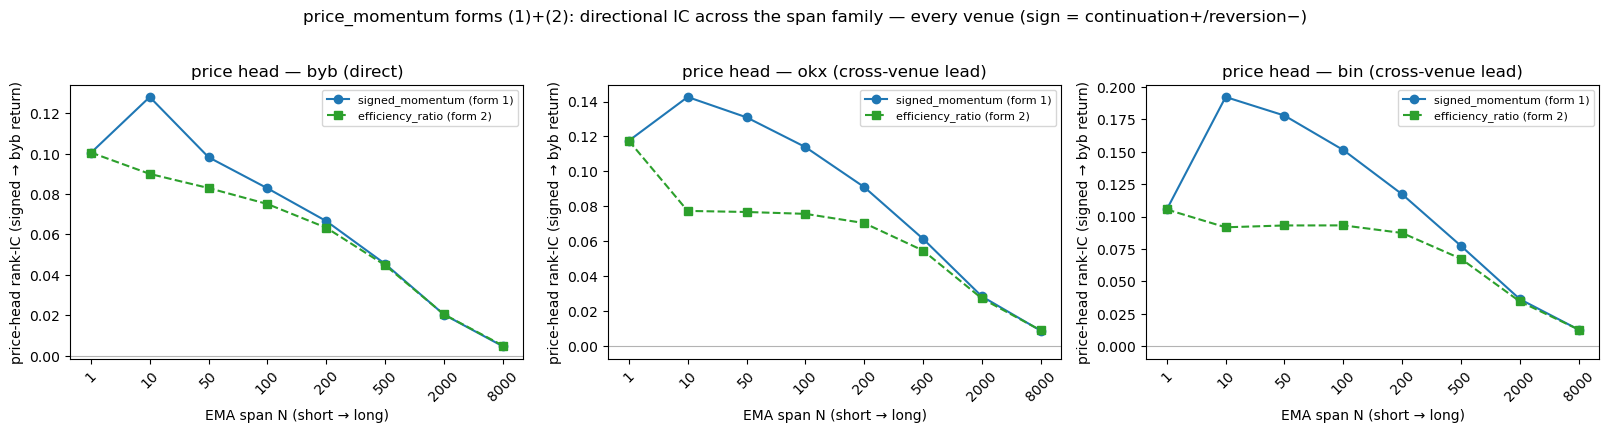

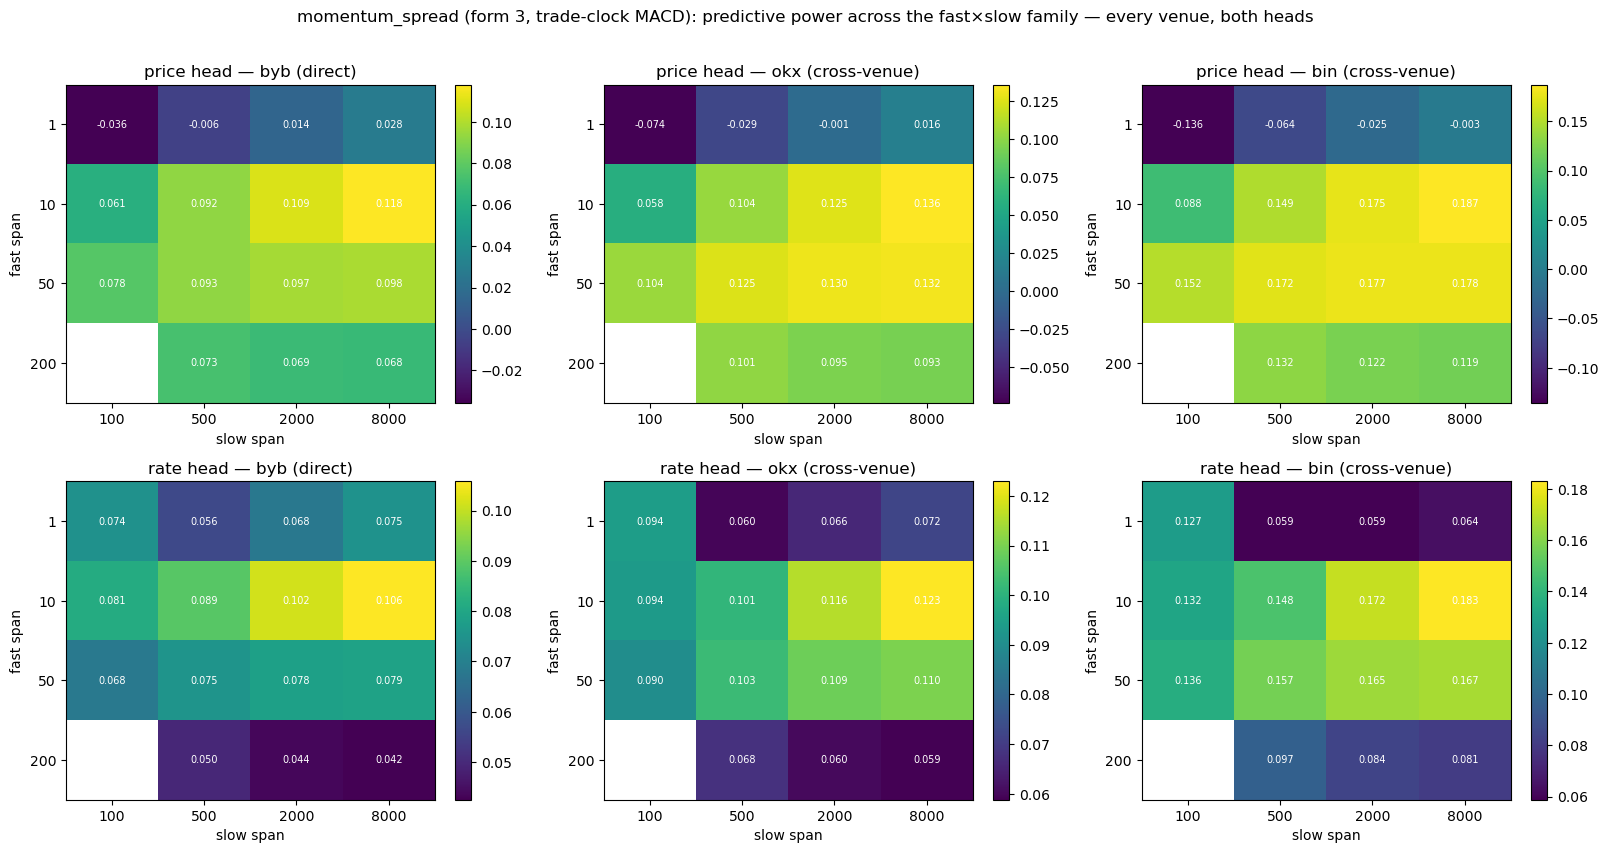

picked scales off the family (per venue — IN-SAMPLE argmax; span is a hyperparameter NOT re-picked inside the OOS folds):
  byb:  price head N=  10 IC=+0.128  |  efficiency N=   1 IC=+0.101  |  rate head N=  10 IC=+0.104  |  MACD (10,8000) IC=+0.118
  okx:  price head N=  10 IC=+0.143  |  efficiency N=   1 IC=+0.118  |  rate head N=  10 IC=+0.123  |  MACD (10,8000) IC=+0.136
  bin:  price head N=  10 IC=+0.192  |  efficiency N=   1 IC=+0.105  |  rate head N=  10 IC=+0.187  |  MACD (10,8000) IC=+0.187


In [5]:
# rate-head target = byb moves (on the trade clock) in the next 100 ms ÷ λ_ev (the rate yardstick).
fwd_count = (cum_mv[np.searchsorted(byb_rx, anchor_ts + HORIZON_NS, "right")]
             - cum_mv[np.searchsorted(byb_rx, anchor_ts, "right")])            # byb mid-moves over the next 100 ms
rate_target = fwd_count / np.maximum(lam_at_anchor, 1e-9)   # count ÷ λ_ev ∝ "more/fewer moves than usual" (λ_ev is moves/sec over 100 ms, so this carries units of seconds; the constant horizon factor drops out of the rank correlation)

# --- RAW-FIRST scale gate (decides normalisation for form 1): measure signed_ret's scale across vol buckets, raw vs /σ_ev ---
vol_decile = np.digitize(vol_level, np.nanpercentile(vol_level[np.isfinite(vol_level)], np.arange(10, 100, 10)))
def scale_across_vol(x):                             # max/min of the per-decile std — the HARD regime-invariance number (want <~3)
    b = [np.nanstd(x[vol_decile == d]) for d in range(10)]; b = [v for v in b if np.isfinite(v) and v > 0]
    return max(b) / min(b)
raw_scale  = scale_across_vol(signed_return_raw("byb", 50))         # form (1) RAW: bare signed drift (suspected non-invariant)
norm_scale = scale_across_vol(signed_return_momentum("byb", 50))    # form (1) /σ_ev candidate
eff_scale  = scale_across_vol(trend_efficiency_ratio("byb", 50))    # form (2) bounded ratio (expected invariant raw)
print(f"scale across vol buckets (HARD gate, want <~3):  signed_ret RAW {raw_scale:.2f}  |  signed_ret/σ_ev {norm_scale:.2f}  |  efficiency_ratio {eff_scale:.2f}")
NORMALISE_SIGNED = raw_scale > 3.0                  # the DECISION, measured not assumed: ship raw if it passes, else /σ_ev
print(f"DECISION — signed_return_momentum: {'FAILS raw -> ship /σ_ev (normalised)' if NORMALISE_SIGNED else 'PASSES raw -> ship RAW (no σ_ev division)'}")
def signed_momentum(ex, span):                      # the SHIPPED form-1, chosen by the gate above
    return signed_return_momentum(ex, span) if NORMALISE_SIGNED else signed_return_raw(ex, span)

# Sweep the family for EVERY venue, BOTH heads. signed_momentum & efficiency are single-span (sweep over SPANS);
# momentum_spread is a fast/slow pair (full grid). Diagnostic IN-SAMPLE rank-IC at each cell (used ONLY to PICK a scale; re-scored OOS in the §5 gates).
def ic_signed(x): return spearmanr(x, target).statistic             # price head: signed feature -> byb signed return
def ic_absrate(x): return spearmanr(np.abs(x), rate_target).statistic  # rate head: |feature| -> byb move count (diagnostic)

sm_price = {ex: np.array([ic_signed(signed_momentum(ex, s)) for s in SPANS]) for ex in EXCHANGES}     # signed_momentum -> direction
sm_rate  = {ex: np.array([ic_absrate(signed_momentum(ex, s)) for s in SPANS]) for ex in EXCHANGES}    # |signed_momentum| -> count
ef_price = {ex: np.array([ic_signed(trend_efficiency_ratio(ex, s)) for s in SPANS]) for ex in EXCHANGES}
# verify the efficiency ratio is genuinely bounded
eff_min = min(np.nanmin(trend_efficiency_ratio(ex, s)) for ex in EXCHANGES for s in SPANS)
eff_max = max(np.nanmax(trend_efficiency_ratio(ex, s)) for ex in EXCHANGES for s in SPANS)
print(f"trend_efficiency_ratio range over the whole family/venues: [{eff_min:+.3f}, {eff_max:+.3f}]  (must be within [−1, 1])")
assert eff_min >= -1.0 - 1e-9 and eff_max <= 1.0 + 1e-9, "efficiency ratio escaped [−1,1] — abs/signed leg mismatch"

# form (3) momentum_spread: full fast×slow grid, per venue, both heads
spread_price = {ex: np.full((len(FAST), len(SLOW)), np.nan) for ex in EXCHANGES}
spread_rate  = {ex: np.full((len(FAST), len(SLOW)), np.nan) for ex in EXCHANGES}
for ex in EXCHANGES:
    for i, nf in enumerate(FAST):
        for j, ns in enumerate(SLOW):
            if nf >= ns: continue
            d = momentum_spread(ex, nf, ns)
            spread_price[ex][i, j] = ic_signed(d)
            spread_rate[ex][i, j]  = ic_absrate(d)

# plot: forms (1)+(2) as per-venue span curves (price head, home) ; momentum_spread as a fast×slow heat-map (both heads)
fig, axes = plt.subplots(1, len(EXCHANGES), figsize=(5.4 * len(EXCHANGES), 4.2), squeeze=False)
for col, ex in enumerate(EXCHANGES):
    ax = axes[0][col]
    ax.plot(range(len(SPANS)), sm_price[ex], "o-", color="C0", label="signed_momentum (form 1)")
    ax.plot(range(len(SPANS)), ef_price[ex], "s--", color="C2", label="efficiency_ratio (form 2)")
    ax.axhline(0, color="0.7", lw=0.8); ax.set_xticks(range(len(SPANS))); ax.set_xticklabels(SPANS, rotation=45)
    ax.set_xlabel("EMA span N (short → long)"); ax.set_ylabel("price-head rank-IC (signed → byb return)")
    tag = "byb (direct)" if ex == "byb" else f"{ex} (cross-venue lead)"
    ax.set_title(f"price head — {tag}"); ax.legend(fontsize=8)
fig.suptitle("price_momentum forms (1)+(2): directional IC across the span family — every venue (sign = continuation+/reversion−)", y=1.02)
fig.tight_layout(); plt.show()

fig, axes = plt.subplots(2, len(EXCHANGES), figsize=(5.4 * len(EXCHANGES), 8.4), squeeze=False)
for row, (grids, head) in enumerate([(spread_price, "price head: signed MACD -> byb return"),
                                     (spread_rate,  "rate head: |MACD| -> byb move count")]):
    for col, ex in enumerate(EXCHANGES):
        ax = axes[row][col]; grid = grids[ex]; im = ax.imshow(grid, cmap="viridis", aspect="auto")
        ax.set_xticks(range(len(SLOW))); ax.set_xticklabels(SLOW); ax.set_xlabel("slow span")
        ax.set_yticks(range(len(FAST))); ax.set_yticklabels(FAST); ax.set_ylabel("fast span")
        tag = "byb (direct)" if ex == "byb" else f"{ex} (cross-venue)"
        ax.set_title(f"{head.split(':')[0]} — {tag}")
        for i in range(len(FAST)):
            for j in range(len(SLOW)):
                if np.isfinite(grid[i, j]): ax.text(j, i, f"{grid[i, j]:.3f}", ha="center", va="center", color="w", fontsize=7)
        fig.colorbar(im, ax=ax, fraction=0.046)
fig.suptitle("momentum_spread (form 3, trade-clock MACD): predictive power across the fast×slow family — every venue, both heads", y=1.01)
fig.tight_layout(); plt.show()

# pick the best span/cell PER VENUE, PER HEAD off the grids. CAVEAT (in-sample span selection): best_span/best_cell
# take the argmax of an IN-SAMPLE |IC| over the WHOLE grid (test folds included), so the CHOSEN SPAN is itself an
# in-sample hyperparameter — the §5 walk-forward re-fits coefficients OOS but does NOT re-pick the span inside each fold.
def best_span(curve): return int(np.nanargmax(np.abs(curve)))        # strongest |IC| span (continuation OR reversion) — IN-SAMPLE
def best_cell(grid):  return np.unravel_index(np.nanargmax(np.abs(grid)), grid.shape)
sm_member     = {ex: best_span(sm_price[ex]) for ex in EXCHANGES}    # form (1) price-head span per venue
ef_member     = {ex: best_span(ef_price[ex]) for ex in EXCHANGES}    # form (2) price-head span per venue
rate_member   = {ex: best_span(sm_rate[ex])  for ex in EXCHANGES}    # form (1) rate-head span per venue (|feature|->count diagnostic pick)
spread_member = {ex: best_cell(spread_price[ex]) for ex in EXCHANGES}  # form (3) price-head (fast,slow) per venue
print("picked scales off the family (per venue — IN-SAMPLE argmax; span is a hyperparameter NOT re-picked inside the OOS folds):")
for ex in EXCHANGES:
    si = sm_member[ex]; ei = ef_member[ex]; ri = rate_member[ex]; fi, fj = spread_member[ex]
    print(f"  {ex:>3}:  price head N={SPANS[si]:>4} IC={sm_price[ex][si]:+.3f}  |  efficiency N={SPANS[ei]:>4} IC={ef_price[ex][ei]:+.3f}"
          f"  |  rate head N={SPANS[ri]:>4} IC={sm_rate[ex][ri]:+.3f}  |  MACD ({FAST[fi]},{SLOW[fj]}) IC={spread_price[ex][fi, fj]:+.3f}")

**Reading the heat-maps.** The **price head** is where this feature lives, and the sign is **positive —
continuation**: a venue that has just trended up tends to keep ticking up over the next 100 ms. The IC
peaks at the **short span N=10 for every venue** and decays monotonically toward 0 by N≥2000, exactly the
short-horizon-autocorrelation story of §1. On this block **bin leads** (+0.192 in-sample at N=10), ahead
of okx (+0.143) and byb's own drift (+0.128). The **RAW-FIRST scale gate PASSES raw** — `signed_ret`'s
scale across vol buckets is **1.12** (≪ 3), so `signed_return_momentum` ships **RAW** (no σ_ev division);
`trend_efficiency_ratio` is bounded `[−1,1]` (range exactly `[−1.000, +1.000]`, scale 1.07) and ships raw
too. The efficiency ratio (form 2) peaks at the freshest N=1 (byb +0.101, okx +0.118, bin +0.105) — a
weaker read of the same drift. The **MACD** (form 3) peaks at (fast=10, slow=8000) per venue but at an IC
(byb +0.118, okx +0.136, bin +0.187) ≈ the bare N=10 signed-drift, i.e. it is mostly the fast leg. We keep
**every** venue and only pick the best time-scale per head per venue (in-sample; re-scored OOS by the gates
below).

> But the IC-max span is only **half** the answer — it picks the single best span per head and says nothing
> about whether a *second* time-scale carries signal the first doesn't. The next cell re-scores the whole
> span family **conditional on the chosen pick** — `partial-IC(span | chosen)` per head — and decides, OOS,
> whether keeping a distinct second span actually adds.

does a 2nd span add over the pick? — price head: conditional partial-IC (in-sample screen) + walk-forward joint-vs-solo OOS:


  byb: best alt N=1 IC|best +0.067;  OOS joint +0.124 vs solo +0.123 (Δ+0.000)  ->  one span suffices (no OOS gain)


  okx: best alt N=1 IC|best +0.093;  OOS joint +0.132 vs solo +0.132 (Δ+0.000)  ->  one span suffices (no OOS gain)


  bin: best alt N=1 IC|best +0.091;  OOS joint +0.176 vs solo +0.176 (Δ-0.000)  ->  one span suffices (no OOS gain)
does a 2nd span add over the pick? — rate head: conditional partial-IC (in-sample screen) + walk-forward joint-vs-solo OOS:


  byb: best alt N=8000 IC|best +0.054;  OOS joint +0.085 vs solo +0.087 (Δ-0.001)  ->  one span suffices (no OOS gain)


  okx: best alt N=1 IC|best +0.075;  OOS joint +0.101 vs solo +0.101 (Δ+0.000)  ->  one span suffices (no OOS gain)


  bin: best alt N=1 IC|best +0.088;  OOS joint +0.163 vs solo +0.163 (Δ-0.000)  ->  one span suffices (no OOS gain)


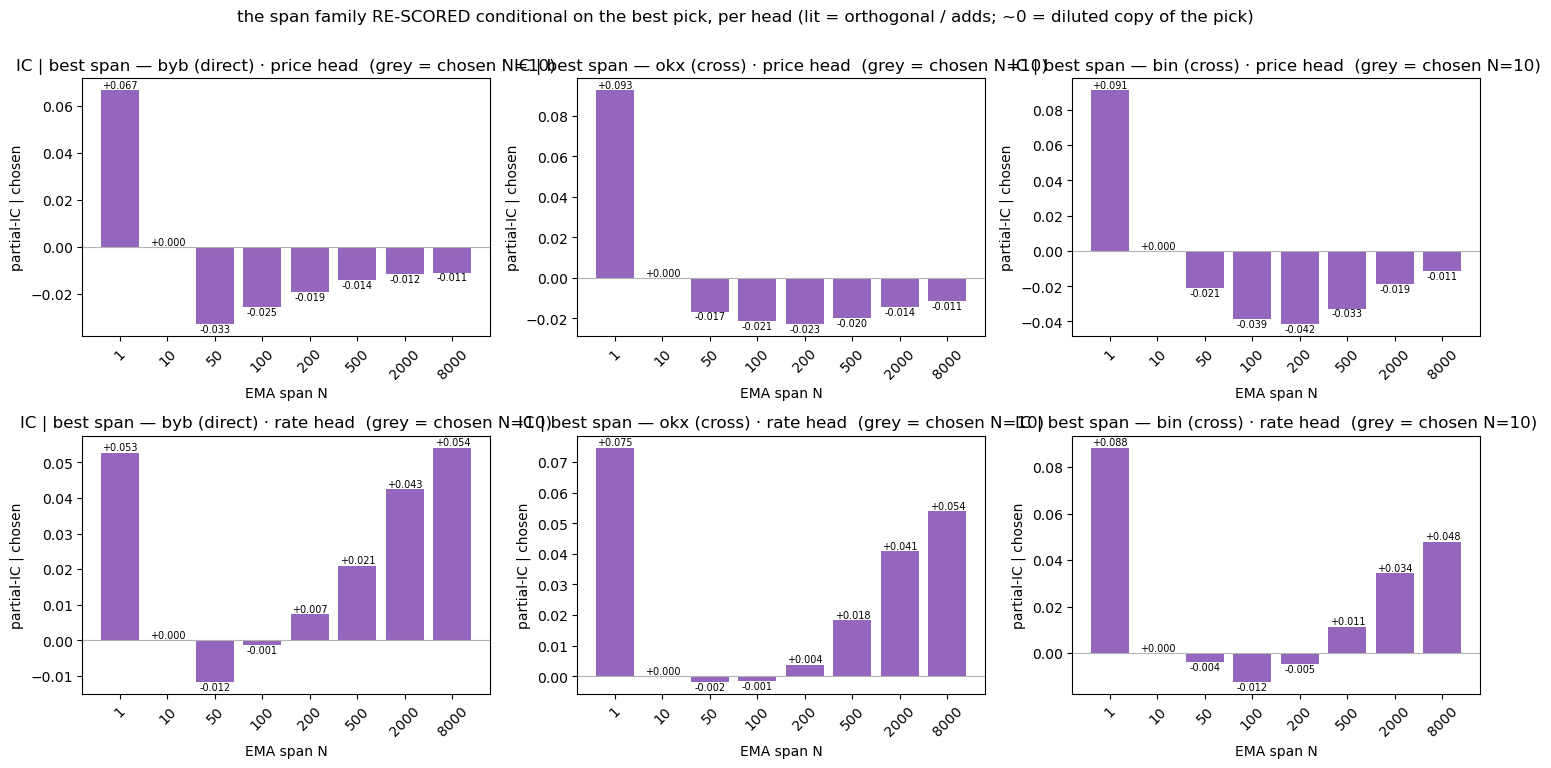

In [6]:
# === Does a SECOND time-scale ADD over the pick? — the span family RE-SCORED conditional on the best member, PER HEAD ===
# Selection lives here in §6. We picked the best span per head by IC; now re-score the WHOLE span family as
# partial-IC(span | chosen) -- each span's IC against the head's target, CONTROLLING for the span we picked (the
# same partial-IC tool the echo-netting cell uses; control = the chosen span, not the trailing move). signed_momentum
# is a single-span family, so the re-scored sweep is 1-D (per head, per venue) — rendered as a bar/line, not a heat-map.
# A span still LIT adds signal ORTHOGONAL to the pick; a span that COLLAPSES to ~0 is a diluted copy. The bars are
# in-sample, so the keep/drop DECISION is the walk-forward joint-vs-solo OOS IC (wf_ic, imported in §5).
def _pic(f, y, c):                                                   # partial rank-IC of f with y, controlling for c
    m = np.isfinite(f) & np.isfinite(y) & np.isfinite(c)
    if m.sum() <= 100: return np.nan
    rfy = spearmanr(f[m], y[m]).statistic; rfc = spearmanr(f[m], c[m]).statistic; rcy = spearmanr(c[m], y[m]).statistic
    return (rfy - rfc * rcy) / np.sqrt(max((1.0 - rfc**2) * (1.0 - rcy**2), 1e-12))

# Per head: feat() maps a span to its scored feature, tgt is the head's target, member is the in-sample span pick.
HEADS = [("price head", lambda ex, n: signed_momentum(ex, n),         target,      sm_member),
         ("rate head",  lambda ex, n: np.abs(signed_momentum(ex, n)), rate_target, rate_member)]
fig, axes = plt.subplots(len(HEADS), len(EXCHANGES), figsize=(5.0 * len(EXCHANGES), 3.8 * len(HEADS)), squeeze=False)
second = {}
for row, (head, feat, tgt, member) in enumerate(HEADS):
    print(f"does a 2nd span add over the pick? — {head}: conditional partial-IC (in-sample screen) + walk-forward joint-vs-solo OOS:")
    for col, ex in enumerate(EXCHANGES):
        ci = member[ex]; chosen = feat(ex, SPANS[ci])
        cond = np.array([0.0 if si == ci else _pic(feat(ex, s), tgt, chosen) for si, s in enumerate(SPANS)])
        ax = axes[row][col]
        ax.bar(range(len(SPANS)), cond, color=["0.4" if si == ci else "C4" for si in range(len(SPANS))])
        ax.axhline(0, color="0.7", lw=0.8); ax.set_xticks(range(len(SPANS))); ax.set_xticklabels(SPANS, rotation=45)
        ax.set_xlabel("EMA span N"); ax.set_ylabel("partial-IC | chosen")
        tag = "byb (direct)" if ex == "byb" else f"{ex} (cross)"
        ax.set_title(f"IC | best span — {tag} · {head}  (grey = chosen N={SPANS[ci]})")
        for si, v in enumerate(cond):
            if np.isfinite(v): ax.text(si, v, f"{v:+.3f}", ha="center", va="bottom" if v >= 0 else "top", fontsize=7)
        cand = np.where(np.arange(len(SPANS)) == ci, np.nan, np.abs(cond))
        bi = int(np.nanargmax(cand)) if np.isfinite(cand).any() else ci                # the most-orthogonal alternative span (in-sample screen)
        f1, f2 = chosen, feat(ex, SPANS[bi])
        solo, joint = wf_ic([f1], tgt), wf_ic([f1, f2], tgt)                           # OOS: chosen alone vs the pair
        keep = bool((joint - solo) >= 0.01)                                            # the OOS joint gain DECIDES
        second[(head, ex)] = bi if keep else None
        print(f"  {ex}: best alt N={SPANS[bi]} IC|best {cond[bi]:+.3f};  OOS joint {joint:+.3f} vs solo {solo:+.3f} (Δ{joint - solo:+.3f})"
              f"  ->  {'KEEP 2nd span (adds OOS)' if keep else 'one span suffices (no OOS gain)'}")
fig.suptitle("the span family RE-SCORED conditional on the best pick, per head (lit = orthogonal / adds; ~0 = diluted copy of the pick)", y=1.005)
fig.tight_layout(); plt.show()

**Does a *second* time-scale add — per head?** The IC sweep picks the best span per head; a second span is only
worth feeding if it carries signal the first doesn't. We test that by **re-scoring the whole span family conditional
on the chosen pick** — each span's IC recomputed as `partial-IC(span | chosen)`: its predictive power against the
head's target **controlling for the span we already picked** (the same partial-IC tool the echo-netting cell
uses; control = the chosen span). A span that stays **lit** is **orthogonal** — it adds new signal — while
a span that **collapses to ≈ 0** is a diluted copy of the pick. Because those bars are **in-sample**, the
keep/drop **decision** is the overfitting-resistant **walk-forward joint-vs-solo** IC
(`wf_ic([chosen, alt]) − wf_ic([chosen])`): keep the second span only when the out-of-sample gain clears the ~0.01
floor. We run it for **both heads** (price → signed feature vs the σ-return target; rate → |feature| vs the count
target), every venue. On this block both find the second span a diluted copy (OOS gain ≈ 0), so one span per head
suffices.

**Now the gates** — and they are **two independent tests**, not one. Every *marginal* number is the
**walk-forward** mean (causal, purged); the one exception is the control-standalone **stratified** IC, which is
in-sample decoupled (its out-of-sample confirmation comes from the multi-block harness in `tools/oss`).

One caveat for **both heads**: the span is chosen by the in-sample heat-map *above* over the
**whole** block, so the walk-forward IC below is **post-selection and provisional** — mildly optimistic,
since the test folds also informed the span pick. Held-out span selection is deferred to the multi-block
`tools/oss` harness; here the choice is among a small 7-span family (and a 4×4 MACD grid) of near-identical
neighbours, so the selection bias is expected to be small (we don't measure it on this single block).

**Gate A — regime invariance** (the feature *alone*): is the feature's distribution **stable against our regime
diagnostics**, or does it *leak* it? **Control-free** checks: **scale** — its std across vol buckets (max/min,
want **< ~3**); and then, for **both the signed feature *and* its magnitude `|feature|`** (the rate head
receives the *signed* feature and can learn its magnitude), two leak modes against **both
regime coordinates** (vol *and* rate level): **tracking** — `|IC(·, level)|` ≈ 0 (the monotone test, want
**< ~0.05** for the signed feature, **< ~0.1** for the magnitude), and **dispersion** — the spread of its
per-decile *means* (want **< ~0.1**), which catches a *non-monotone* leak the monotone IC misses. Fail any
one of them = a level in disguise, not a feature. *(The scale check is exactly the RAW-FIRST proof behind §5's
normalisation decision; the bounded efficiency ratio should read scale ≈ 1.)*

**Gate B — predictive signal**: does it predict? Because *a control can itself be a valid feature*,
"signal **over** the controls" only makes sense for a feature that **isn't** a control. `price_momentum`
is a directional **alpha** (not a regime descriptor), so Gate B is its **marginal** rank-IC over the
regime-invariant controls (the momenta — **never** the raw levels), all exchanges together and each on
its own, want ≳ 0.01. **Mechanical-coupling guard:** the gate scores the **σ_ev price target**
(`fwd_return/σ_ev`) by default. A **signed price-head alpha** that divides by the same σ_ev (the
normalised form) needs no stratification — a signed numerator makes the shared-σ_ev coupling negligible —
so `STRAT_VAR = None`. We still print the within-σ_ev stratified standalone IC below as a *confirmation*
that the unstratified IC isn't a σ_ev artefact.
*Regime-stable* (companion): is Gate B still positive **within** calm, mid, and wild vol — not a one-regime artefact?

In [7]:
# Gates on the set of per-exchange features — symmetric; KEEP ALL exchanges. Marginal value is checked
# JOINTLY (do the exchanges together add over the controls?) and per-exchange (does each contribute?), never by picking one.
# GATE B — predictive signal.
#   alpha (or a control's CROSS-venue leg): MARGINAL rank-IC over the base momenta — a lead test.
# signal_ic / signal_ic_by_regime / stratified_ic / ic all come from boba.research.gates (the §5 wrappers
# bind base / FEATURE_KIND / STRAT_VAR / vol_regime). price_momentum is an alpha, so all legs take the marginal branch.

sm_feat = {ex: signed_momentum(ex, SPANS[sm_member[ex]]) for ex in EXCHANGES}   # the chosen price-head feature per exchange
joint = signal_ic(list(sm_feat.values()), own=False)
strat = signal_ic_by_regime(list(sm_feat.values()), own=False)
pci = wf_marginal_ci(list(sm_feat.values()), target)   # H5: per-fold spread + block-bootstrap CI for the headline marginal
print(f"joint Gate B marginal {joint:.3f}  |  per-fold {pci['per_fold']} (positive in {pci['pos']}/{pci['nf']})  |  block-bootstrap 90% CI [{pci['ci'][0]}, {pci['ci'][1]}]  (block ~{pci['block_len']} anchors ~{pci['block_s']}s)")
rep = sm_feat[EXCHANGES[0]]                            # representative leg — for the momenta-overlap sanity print only (Gate A runs PER EXCHANGE below)
# GATE A — regime invariance (vol_level/rate_level are the regime COORDINATE, never controls), run PER EXCHANGE
# (Gate A is a property of the output DISTRIBUTION, which differs by venue — bin is sub-ms fresh, byb/okx stale):
# scale, plus the signed feature AND its magnitude |feature| (which the signed-fed rate head can learn), each checked
# two ways x two coordinates — TRACK = |IC(., vol/rate level)| (monotone drift) and DISP = per-decile-mean dispersion.
# LOW-1 sanity: an "alpha" must NOT be a hidden regime descriptor -> its overlap with the momenta is small.
print(f"FEATURE_KIND={FEATURE_KIND!r} | feature vs momenta |IC|: rate {abs(ic(rep, rate_momentum)):.3f} vol {abs(ic(rep, vol_momentum)):.3f}  (large for an 'alpha' => it's really a control)")
gate_rows = [dict(gate="B · signal", detail="all exchanges together — marginal over the invariant controls", value=joint)]
gate_rows += [dict(gate="B · signal", detail=f"{ex} alone — marginal over the controls",
                   value=signal_ic([sm_feat[ex]], own=False)) for ex in EXCHANGES]
# σ_ev-coupling confirmation: the signed feature (when normalised) and the σ_ev price target both divide by σ_ev.
# A SIGNED numerator should decouple that shared denominator — verify it: standalone IC WITHIN σ_ev strata ≈ unstratified
# standalone IC means σ_ev isn't manufacturing the rank-IC (spurious ratio corr).
gate_rows += [dict(gate="B · coupling", detail=f"{ex} — signed feature standalone IC, unstratified", value=round(ic(sm_feat[ex], target), 3)) for ex in EXCHANGES]
gate_rows += [dict(gate="B · coupling", detail=f"{ex} — signed standalone IC WITHIN σ_ev strata (≈ unstratified => σ_ev not manufacturing it)", value=round(stratified_ic(sm_feat[ex], target, sigma_at_anchor), 3)) for ex in EXCHANGES]
for ex in EXCHANGES:                                   # GATE A PER EXCHANGE (worst coordinate per check) — every venue, since the output distribution differs by venue
    a = gate_a(sm_feat[ex])
    gate_rows += [dict(gate=f"A · regime-inv ({ex})", detail=f"feature scale across vol buckets (max/min) — HARD, want < ~3 — {'NORMALISED /σ_ev' if NORMALISE_SIGNED else 'RAW'}", value=a["scale"]),
                  dict(gate=f"A · regime-inv ({ex})", detail="|IC(feature, vol/rate level)| — signed mean-track, worst coord; want < ~0.05", value=a["track"]),
                  dict(gate=f"A · regime-inv ({ex})", detail="|IC(|feature|, vol/rate level)| — magnitude track (the signed-fed rate head can learn it), worst coord; want < ~0.1", value=a["mag"]),
                  dict(gate=f"A · regime-inv ({ex})", detail="non-monotone leak — per-decile-mean dispersion (mean & magnitude), worst; want < ~0.1", value=a["disp"])]
gate_rows += [dict(gate="regime-stable", detail=f"signal within {nm}-vol (companion: stay positive)", value=strat.get(r, float("nan")))
              for r, nm in [(0, "calm"), (1, "mid"), (2, "wild")]]
pl.Config.set_tbl_rows(40); pl.Config.set_fmt_str_lengths(70)
pl.DataFrame(gate_rows)

joint Gate B marginal 0.177  |  per-fold [0.169, 0.188, 0.135, 0.16, 0.233] (positive in 5/5)  |  block-bootstrap 90% CI [0.171, 0.184]  (block ~2000 anchors ~100.0s)


FEATURE_KIND='alpha' | feature vs momenta |IC|: rate 0.002 vol 0.017  (large for an 'alpha' => it's really a control)


gate,detail,value
str,str,f64
"""B · signal""","""all exchanges together — marginal over the invariant controls""",0.177
"""B · signal""","""byb alone — marginal over the controls""",0.11
"""B · signal""","""okx alone — marginal over the controls""",0.126
"""B · signal""","""bin alone — marginal over the controls""",0.174
"""B · coupling""","""byb — signed feature standalone IC, unstratified""",0.128
"""B · coupling""","""okx — signed feature standalone IC, unstratified""",0.143
"""B · coupling""","""bin — signed feature standalone IC, unstratified""",0.192
"""B · coupling""","""byb — signed standalone IC WITHIN σ_ev strata (≈ unstratified => σ_ev …",0.128
"""B · coupling""","""okx — signed standalone IC WITHIN σ_ev strata (≈ unstratified => σ_ev …",0.141


**Conclusion (read off the table).** `price_momentum`'s home is the **price head** — a *signed*
directional feature — and **Gate B is a clear pass**: it adds **+0.177** walk-forward rank-IC over the
controls *jointly* (positive in **5/5** OOS folds, tight block-bootstrap 90% CI **[0.171, 0.184]**), and
each venue contributes on its own (**bin +0.174, okx +0.126, byb +0.110**), far above the ~0.01 floor;
here **bin is the strongest single leg**, not byb's own drift. The sign is **positive (continuation)** and
the controls carry ≈0 directional signal (§5), so the marginal ≈ the raw standalone IC. The two
**coupling** rows confirm the shared σ_ev isn't manufacturing it: the within-σ_ev stratified standalone IC
barely moves (byb 0.128→0.128, okx 0.143→0.141, bin 0.192→0.189) — a signed numerator decouples the shared
denominator (the reason `STRAT_VAR=None`). And its overlap with the momenta is tiny (|IC| rate 0.002, vol
0.017), confirming it really is an alpha.

**Gate A is a *split verdict*, and we report it honestly.** Run per exchange, the **signed** feature is
regime-clean — **scale** wanders only **1.24 / 1.31 / 1.39×** (byb / okx / bin; ≪ 3, the RAW-FIRST proof
behind shipping raw) and the **signed mean-track** is **0.008 / 0.003 / 0.014** (≪ 0.05). But the
feature's **magnitude `|signed_ret|` tracks the volatility regime** — **mag-track 0.192 / 0.207 / 0.175**
and **dispersion 0.267 / 0.299 / 0.333**, both well **over** the ~0.1 bars. This is expected and benign for
the price head: a drift's *size* is essentially a volatility proxy (bigger moves in wilder markets), so
`|feature|` leaks the regime even though the *direction* the price head consumes does not. It is a **real
flag for the rate head** (which can learn `|·|`) and is exactly why the rate-span feature gets its own
gates below. The **companion** keeps the price-head marginal positive — and rising — across regimes
(**0.157 / 0.174 / 0.205** calm / mid / wild). Verdict for the **price head**: Gate B clears every leg and
the *signed* signal is regime-invariant; the magnitude leak is noted and carried into the rate-head gate.
The §10 verdict cites the **echo-netted** number from the echo-netting check, since momentum's headline
forward IC is partly the move already underway (a sizeable backward/echo IC on the short-N legs).

**Now the rate head — its own gates, against the count target.** The block above gated the *price-span*
feature against the σ_ev **price** target. The rate head is fed a **different-span** feature (the
`rate_member` pick) and predicts the **count** target, so its verdict is **not** inherited from the price
gates — it gets the same two-gate battery here.

The rate head's signal lives in the **magnitude**: `|feature| → count` is the §6 diagnostic, and the model
is fed the **signed** feature and recovers `|·|` itself (a nonlinear head can). So **Gate B scores
`|feature|`** — a *linear* score on the signed feature would read ≈ 0 precisely because the count
relationship is symmetric, so `|feature|` is the honest proxy for what the nonlinear rate head extracts.
**Coupling guard:** the price head used `STRAT_VAR=None` because its **signed** numerator decouples the
shared σ_ev; the magnitude path has no sign to decouple it, and `|feature|` shares the byb-activity regime
with `count/λ_ev ∝ 1/λ_ev` — so we add a **within-λ_ev stratified** line per exchange to confirm the
marginal isn't a `1/λ_ev` artefact. **Gate A** is re-run **per exchange** on the rate-span feature (a
distribution property — it differs by venue *and* by span).

In [8]:
# === RATE-HEAD GATES ===
# The price-head gates above ran the price-SPAN feature against the σ_ev price target. The rate head is fed a
# DIFFERENT-span feature (the rate_member pick) and predicts the COUNT target, so its verdict can't be inherited
# from the price gates — it gets the SAME two-gate battery here, against the count target.
#  * The rate head's signal lives in the MAGNITUDE: |feature|->count is the §6 diagnostic; the model is fed the SIGNED
#    feature and recovers |.| internally (a nonlinear head can). So Gate B scores |feature| — a LINEAR score on the signed
#    feature reads ~0 because the count relationship is symmetric; |feature| is the honest proxy.
#  * Coupling guard: |feature| ~ 1/σ_ev while count/λ_ev ~ 1/λ_ev share the byb-activity regime — add a within-λ_ev
#    stratified line per exchange to confirm the marginal is not a 1/λ_ev artefact.
#  * Gate A is re-run PER EXCHANGE on the rate-span feature (a distribution property — it differs by venue AND by span).
sm_rate_feat = {ex: signed_momentum(ex, SPANS[rate_member[ex]]) for ex in EXCHANGES}
mag_rate     = {ex: np.abs(sm_rate_feat[ex]) for ex in EXCHANGES}

joint_rate  = signal_ic(list(mag_rate.values()), own=False, tgt=rate_target)            # |feature|->count, marginal over the controls, all venues together
strat_rate  = signal_ic_by_regime(list(mag_rate.values()), own=False, tgt=rate_target)  # the calm/mid/wild companion
rci = wf_marginal_ci(list(mag_rate.values()), rate_target)   # H5: per-fold spread + block-bootstrap CI for the rate-head headline marginal
print(f"joint Gate B (rate) marginal {joint_rate:.3f}  |  per-fold {rci['per_fold']} (positive in {rci['pos']}/{rci['nf']})  |  block-bootstrap 90% CI [{rci['ci'][0]}, {rci['ci'][1]}]  (block ~{rci['block_len']} anchors ~{rci['block_s']}s)")
# gate_a (worst-coordinate Gate A, used for both heads) is bound in §5.

rate_rows  = [dict(gate="B · signal (rate)", detail="all exchanges together — marginal |feature|->count over the controls; want >~ 0.01", value=joint_rate)]
rate_rows += [dict(gate="B · signal (rate)", detail=f"{ex} alone — marginal |feature|->count over the controls",
                   value=signal_ic([mag_rate[ex]], own=False, tgt=rate_target)) for ex in EXCHANGES]
rate_rows += [dict(gate="B · coupling (rate)", detail=f"{ex} — |feature|->count WITHIN λ_ev strata (stays +ve => not a 1/λ_ev artefact)",
                   value=round(stratified_ic(mag_rate[ex], rate_target, lam_at_anchor), 3)) for ex in EXCHANGES]
for ex in EXCHANGES:
    a = gate_a(sm_rate_feat[ex])
    rate_rows += [dict(gate=f"A · regime-inv ({ex})", detail="feature scale across vol buckets (max/min) — HARD, want < ~3", value=a["scale"]),
                  dict(gate=f"A · regime-inv ({ex})", detail="|IC(feature, vol/rate level)| — signed mean-track, worst coord; want < ~0.05", value=a["track"]),
                  dict(gate=f"A · regime-inv ({ex})", detail="|IC(|feature|, vol/rate level)| — the rate head sees |feature|, worst coord; want < ~0.1", value=a["mag"]),
                  dict(gate=f"A · regime-inv ({ex})", detail="non-monotone leak — per-decile-mean dispersion (mean & magnitude), worst; want < ~0.1", value=a["disp"])]
rate_rows += [dict(gate="regime-stable (rate)", detail=f"|feature|->count within {nm}-vol (companion: stay positive)", value=strat_rate.get(r, float("nan")))
              for r, nm in [(0, "calm"), (1, "mid"), (2, "wild")]]
pl.Config.set_tbl_rows(40); pl.Config.set_fmt_str_lengths(75)
pl.DataFrame(rate_rows)

joint Gate B (rate) marginal 0.110  |  per-fold [0.09, 0.128, 0.093, 0.102, 0.14] (positive in 5/5)  |  block-bootstrap 90% CI [0.103, 0.115]  (block ~9479 anchors ~474.0s)


gate,detail,value
str,str,f64
"""B · signal (rate)""","""all exchanges together — marginal |feature|->count over the controls; want …",0.11
"""B · signal (rate)""","""byb alone — marginal |feature|->count over the controls""",0.017
"""B · signal (rate)""","""okx alone — marginal |feature|->count over the controls""",0.046
"""B · signal (rate)""","""bin alone — marginal |feature|->count over the controls""",0.103
"""B · coupling (rate)""","""byb — |feature|->count WITHIN λ_ev strata (stays +ve => not a 1/λ_ev artefa…",0.072
"""B · coupling (rate)""","""okx — |feature|->count WITHIN λ_ev strata (stays +ve => not a 1/λ_ev artefa…",0.089
"""B · coupling (rate)""","""bin — |feature|->count WITHIN λ_ev strata (stays +ve => not a 1/λ_ev artefa…",0.159
"""A · regime-inv (byb)""","""feature scale across vol buckets (max/min) — HARD, want < ~3""",1.24
"""A · regime-inv (byb)""","""|IC(feature, vol/rate level)| — signed mean-track, worst coord; want < ~0.0…",0.008


**Conclusion (rate head — read off the table).** The rate-span feature (N=10) gets the same battery
against the **count** target. **Gate B passes**: the marginal `|feature| → count` over the controls is
**+0.110** jointly (positive in **5/5** OOS folds, CI **[0.103, 0.115]**), **+0.103** (bin) and **+0.046**
(okx) on their own above the ~0.01 floor; **byb's own** rate leg is only **+0.017** (echo-dominated,
consistent with the echo-netting read) — kept because leadership rotates, but the weak one. *Within*
**λ_ev strata** the signal stays robustly positive (**0.159** bin, **0.089** okx, **0.072** byb), so the
marginal isn't a `1/λ_ev` arithmetic artefact. The **companion** is positive in every regime (**0.099 /
0.105 / 0.111** calm / mid / wild). **But Gate A confirms the magnitude leak from the price-head table**:
on this same N=10 feature the `|feature|` the rate head actually consumes tracks the regime (mag-track
**0.175–0.207**, dispersion **0.267–0.333**, over the ~0.1 bars) while scale (1.24–1.39) and the signed
mean-track (0.003–0.014) stay clean. So the rate head **carries real `|momentum| → count` signal**, but
part of that magnitude is the volatility regime — the model should lean on it knowing the rate head also
sees the regime momenta as controls. The rate head is a *diagnostic*; momentum's home is the price head.

## Is the edge real prediction, or an echo of the move already underway?

A feature can be perfectly causal and still not *predict*: if its apparent edge is the price move **already
underway** at the anchor, you can't capture it — by the time you observe, decide, and act, that move is gone — and
a purely *contemporaneous* feature can post a positive forward IC from window overlap alone. So before trusting a
forward IC, **net out the echo**: measure the feature's correlation with the **forward** return
(`[anchor, anchor+100 ms]`) *controlling for the move that already happened* (`[anchor−100 ms, anchor]`). The
**backward IC** sizes the echo; the **echo-netted** forward IC is what survives once it's partialled out — the
genuinely forward-looking edge. (It's the same partial-IC tool §6 uses to test a second time-scale — here the
control is the trailing move instead of the chosen span.)

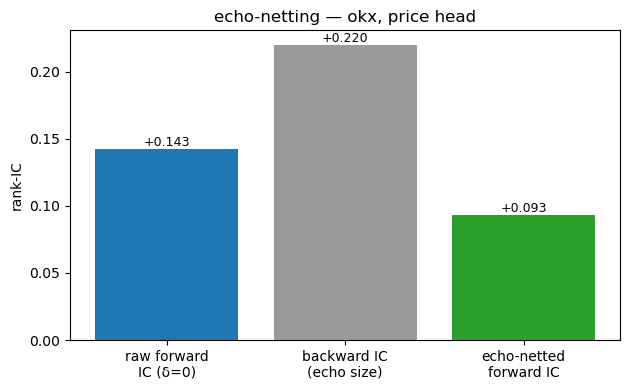

raw forward IC +0.143;  backward (echo) IC +0.220;  echo-netted forward IC +0.093  (the raw->netted shortfall is echo)


In [9]:
# Echo-netting: is the edge real prediction, or just re-reporting the move ALREADY underway at the anchor?
rep_ex = OTHERS[0]                                       # one exchange to illustrate; every feature carries its own
def _ic(feat, ret):
    v = np.isfinite(feat) & np.isfinite(ret)
    return spearmanr(feat[v], ret[v]).statistic if v.sum() > 100 else float("nan")
def _mid_at(t):                                          # byb merged mid at-or-before t (causal)
    idx = np.searchsorted(byb_rx, t, "right") - 1; return np.where(idx < 0, np.nan, byb_mid[np.clip(idx, 0, len(byb_mid) - 1)])   # nan before byb's first quote
def _ret(t0, t1): return np.log(_mid_at(t1) / _mid_at(t0))
def _partial_ic(f, y, t):                                # partial rank-IC of f with y, CONTROLLING for t
    v = np.isfinite(f) & np.isfinite(y) & np.isfinite(t)
    if v.sum() <= 100: return float("nan")
    rfy = spearmanr(f[v], y[v]).statistic; rft = spearmanr(f[v], t[v]).statistic; rty = spearmanr(t[v], y[v]).statistic
    return (rfy - rft*rty) / np.sqrt(max((1.0 - rft**2) * (1.0 - rty**2), 1e-12))

signed = signed_momentum(rep_ex, SPANS[sm_member[rep_ex]])   # the chosen price-head feature (the venue's IC-max signed_momentum span)
_fwd0  = _ret(anchor_ts, anchor_ts + HORIZON_NS)          # forward 100 ms return — what we predict
_trail = _ret(anchor_ts - HORIZON_NS, anchor_ts)          # the move ALREADY underway at the anchor
raw_ic   = _ic(signed, _fwd0)                             # raw forward IC
back_ic  = _ic(signed, _trail)                            # backward IC — sizes the contemporaneous echo
echo_net = _partial_ic(signed, _fwd0, _trail)             # forward IC NETTED of the echo (controls for the trailing move)

fig, ax = plt.subplots(figsize=(6.4, 4.0))
labels = ["raw forward\nIC (δ=0)", "backward IC\n(echo size)", "echo-netted\nforward IC"]
vals = [raw_ic, back_ic, echo_net]
bars = ax.bar(labels, vals, color=["C0", "0.6", "C2"])
ax.axhline(0, color="0.7", lw=0.8); ax.set_ylabel("rank-IC"); ax.set_title(f"echo-netting — {rep_ex}, price head")
for b, v in zip(bars, vals):
    ax.text(b.get_x() + b.get_width() / 2, v, f"{v:+.3f}", ha="center", va="bottom" if v >= 0 else "top", fontsize=9)
fig.tight_layout(); plt.show()
print(f"raw forward IC {raw_ic:+.3f};  backward (echo) IC {back_ic:+.3f};  echo-netted forward IC {echo_net:+.3f}  (the raw->netted shortfall is echo)")

**Net the echo out — don't report a forward IC a contemporaneous predictor could fake.** The cleanest
"is this real prediction?" number is the **echo-netted (partial) forward IC** above: the feature's rank-IC with
the *forward* return *controlling for the trailing* `[anchor−100 ms, anchor]` return. If a big raw IC collapses
once the trailing move is partialled out, the feature was mostly re-reporting the move already underway — report
the **netted** number in the verdict, not the raw IC. (A near-zero netted IC alongside a large backward IC is the
one true non-signal: all echo, no prediction.)

**Cross-venue legs: a freshness lead is *real edge*, not an artifact to coarsen away.** The data is recorded
on a production box in the target datacenter, so each event's `rx_time` is exactly the timing you'd see live —
there is **no recording/snapshot artifact** to rule out. So when okx's book moves before byb's reflects it
(byb/okx top-of-book is stale p90 ~100–160 ms vs bin's sub-ms), that lead is **genuine and exploitable**, and
the *mechanism* (economic price-discovery vs pure latency lead-lag) is irrelevant to P&L. Do **not** coarsen the
foreign feed to byb's cadence — that throws the edge away. *(A freshness lead would only be fake if the
recording's cadence didn't match production — e.g. a backtest on vendor snapshots; not the case here, where the
recording* is *production timing.)*

## 7. What the prediction actually looks like

A single correlation number hides *how* the feature changes the outcome. So group the data by
`price_momentum` (byb's leg, its home) and look at the real distributions the two heads care about:
- **price head (home):** byb's next return for low / middle / high *signed* momentum — it should tilt
  one way as momentum turns positive and the other as it turns negative (the sign of the §6 IC tells you
  which is continuation and which reversion);
- **rate head (diagnostic):** how the number of upcoming byb moves grows as momentum's *magnitude* grows.

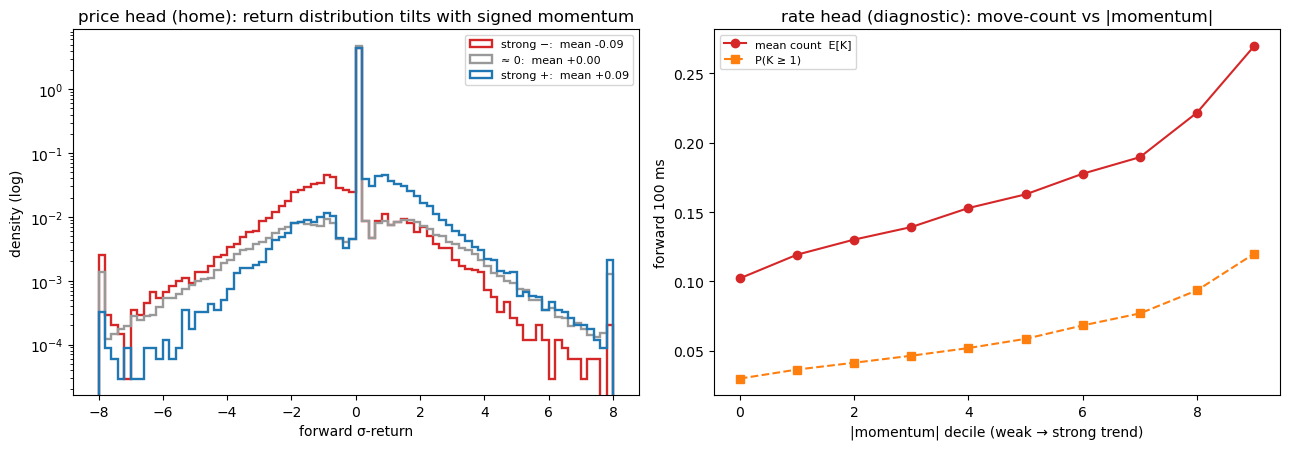

In [10]:
ex0 = "byb"                                                                     # the direct leg, shown to illustrate the shape
signed = signed_momentum(ex0, SPANS[sm_member[ex0]])                            # the price-head pick (home)
absmag = np.abs(signed_momentum(ex0, SPANS[rate_member[ex0]]))                  # the RATE-head span pick of the same feature
fig, (axA, axB) = plt.subplots(1, 2, figsize=(13, 4.6))

# price head (home): forward σ-return distribution across signed-momentum buckets
lo, hi = np.nanpercentile(signed, [10, 90])
groups = [("strong −", signed <= lo, "C3"), ("≈ 0", (signed > lo) & (signed < hi), "0.6"),
          ("strong +", signed >= hi, "C0")]
bins = np.linspace(-8, 8, 81)
for lab, m, col in groups:
    axA.hist(np.clip(target[m & np.isfinite(target)], -8, 8), bins=bins, density=True,
             histtype="step", color=col, lw=1.7, label=f"{lab}:  mean {np.nanmean(target[m]):+.2f}")
axA.set_yscale("log"); axA.set_xlabel("forward σ-return"); axA.set_ylabel("density (log)")
axA.set_title("price head (home): return distribution tilts with signed momentum"); axA.legend(fontsize=8)

# rate head (diagnostic): forward move-count shifts with |momentum|
# raw fwd_count is shown here only for intuition; the rate head's actual target is rate_target = fwd_count / λ_ev (count ÷ λ_ev)
dec = np.digitize(absmag, np.nanpercentile(absmag, np.arange(10, 100, 10)))
axB.plot(range(10), [fwd_count[dec == b].mean() for b in range(10)], "o-", color="C3", label="mean count  E[K]")
axB.plot(range(10), [(fwd_count[dec == b] >= 1).mean() for b in range(10)], "s--", color="C1", label="P(K ≥ 1)")
axB.set_xlabel("|momentum| decile (weak → strong trend)"); axB.set_ylabel("forward 100 ms")
axB.set_title("rate head (diagnostic): move-count vs |momentum|"); axB.legend(fontsize=8)
fig.tight_layout(); plt.show()

**Conclusion.** The feature moves the *actual outcome distributions* the two heads need — not just a
summary number (shown for byb's own flow; the model uses every venue). **Price head (left):** the
forward-return distribution shifts with the *signed* momentum — read the group means in the legend; the
direction of the shift matches the sign of the §6 IC (continuation or reversion), so the sign genuinely
carries direction. **Rate head (right):** the mean move-count `E[K]` and `P(K ≥ 1)` against the
`|momentum|` decile show whether a stronger recent trend also precedes *more* byb activity (a diagnostic —
the model is still fed the signed feature). The picture is the visual counterpart of §6's IC.

## 8. Input shaping for the network

This is a *different* step from §2. There the regime question was whether to divide out volatility (the
RAW-FIRST decision). Here we reshape the chosen feature for the neural network's input — roughly centred,
unit-scale, no wild outliers.

Pick the **lightest** transform that does the job. Plot the feature (left) and compare a few candidates by
how close to a clean bell curve they make it (right — points on the diagonal are perfectly normal). A
symmetric, mild feature needs only a z-score; a fat-tailed one needs more (a robust z + clip, or a
rank-to-normal map). The QQ-plot makes the choice. (Shown for the shipped `signed_momentum`, byb leg.)

feature: std=2.77e-06  skew=+0.03  excess_kurt=10.5  (0 = normal)  [shipped form: RAW]
  z-score            skew=+0.03  excess_kurt=   10.5   max|·|=24.7
  robust + clip ±4   skew=-0.01  excess_kurt=   -0.6   max|·|=4.0
  arcsinh(robust)    skew=-0.00  excess_kurt=    0.1   max|·|=6.7
  rank-Gaussian      skew=-0.00  excess_kurt=   -0.0   max|·|=5.0


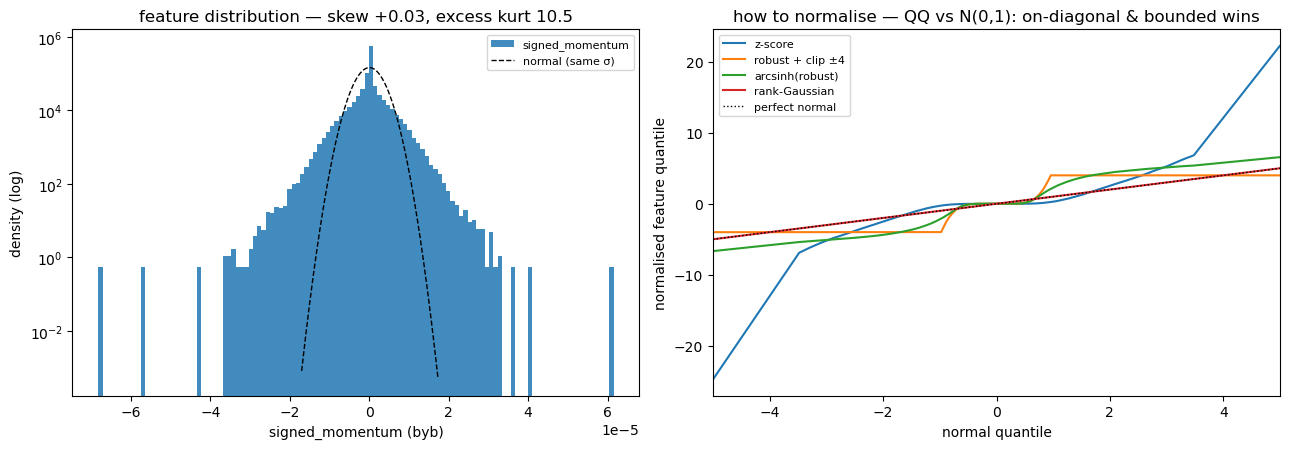

In [11]:
from scipy.stats import skew, kurtosis, rankdata, norm
ex0 = "byb"
f = signed_momentum(ex0, SPANS[sm_member[ex0]]); f = f[np.isfinite(f)]
med = np.median(f); mad = 1.4826 * np.median(np.abs(f - med)) + 1e-300; rz = (f - med) / mad
cand = {"z-score": (f - f.mean()) / (f.std() + 1e-300),
        "robust + clip ±4": np.clip(rz, -4, 4),
        "arcsinh(robust)": np.arcsinh(rz),
        "rank-Gaussian": norm.ppf((rankdata(f) - 0.5) / len(f))}
print(f"feature: std={f.std():.2e}  skew={skew(f):+.2f}  excess_kurt={kurtosis(f):.1f}  (0 = normal)  [shipped form: {'/σ_ev' if NORMALISE_SIGNED else 'RAW'}]")
for name, v in cand.items():
    print(f"  {name:18} skew={skew(v):+.2f}  excess_kurt={kurtosis(v):>7.1f}   max|·|={np.abs(v).max():.1f}")

fig, (axA, axB) = plt.subplots(1, 2, figsize=(13, 4.6))
axA.hist(f, bins=120, density=True, color="C0", alpha=.85, label="signed_momentum")
xg = np.linspace(np.percentile(f, 0.05), np.percentile(f, 99.95), 300)
axA.plot(xg, norm.pdf(xg, f.mean(), f.std()), "k--", lw=1, label="normal (same σ)")
axA.set_yscale("log"); axA.set_xlabel("signed_momentum (byb)"); axA.set_ylabel("density (log)")
axA.set_title(f"feature distribution — skew {skew(f):+.2f}, excess kurt {kurtosis(f):.1f}"); axA.legend(fontsize=8)

q = norm.ppf((np.arange(1, len(f) + 1) - 0.5) / len(f)); sub = np.linspace(0, len(f) - 1, 4000).astype(int)
for name, v in cand.items():
    axB.plot(q[sub], np.sort(v)[sub], lw=1.5, label=name)
axB.plot([-5, 5], [-5, 5], "k:", lw=1, label="perfect normal")
axB.set_xlim(-5, 5); axB.set_xlabel("normal quantile"); axB.set_ylabel("normalised feature quantile")
axB.set_title("how to normalise — QQ vs N(0,1): on-diagonal & bounded wins"); axB.legend(fontsize=8)
fig.tight_layout(); plt.show()

**Conclusion.** The printout settles it. The shipped `signed_momentum` (RAW, byb leg) is centred near 0
and near-**symmetric** (skew **+0.03** — a trend is as likely up as down), but it is sharply **fat-tailed**
(excess kurtosis **10.5**): bursts of one-sided flow leave a large spike, and a plain z-score still reads
**max|·| = 24.7σ**, far past the "no wild outliers" bar. The lightest transform that *meets* it is a
**robust z-score + clip ±4** (excess kurt −0.6, **max|·| = 4.0**); the heavier `arcsinh` (max|·| 6.7) and
rank-Gaussian (max|·| 5.0) flatten the tails further but throw away the trend-strength magnitude that is
part of the signal. So: feed the robust-standardised, clipped `signed_momentum`. The QQ-plot confirms the
robust-clip lands on the diagonal while the raw z-score's tails blow out. The `trend_efficiency_ratio` is
already bounded in `[−1,1]` — it needs only a centring rescale.

**Still to run** (same machinery): whether the feature adds over features we already have;
whether the signal is steady day-to-day; and whether it survives out-of-sample across a
market-regime change. (The leak check *inside* volatility buckets is no longer pending —
Gate A's checks and the regime-stable companion now run it.)

## 9. When is per-exchange worth it? (for poolable features)

Unlike the template's gap (a quantity *between* two exchanges), `price_momentum` is a genuine
**per-exchange** number — each venue's own drift — so the pool / single / per-exchange choice is real
here. The cross-venue edge — if any — is a **lead/lag**: a trend appearing on okx or bin a beat *before*
byb's. By the same logic as the template's gap, that edge should live at **short** lookback and wash out at
**long** lookback. So we sweep the span family and, at a short / medium / long span, compare the three:
- **pooled** — one signed-drift over *all* venues' mid-moves on the shared clock;
- **best single** — the single most predictive venue's momentum (in-sample pick, scored OOS);
- **per-exchange** — all three fed in together.

We score each by **marginal walk-forward** rank-IC over the controls (against byb's next return), to see
where keeping the venues separate pays off. (For a *direct contemporaneous* signal like byb's own momentum,
the pooled/per-exchange comparison is about whether the foreign venues add a genuine cross-venue **lead**
beyond byb's own drift — read it net of the echo from the echo-netting check.)

In [12]:
# pooled signed-drift: sum every venue's Δlog moves onto the shared clock, then the SAME decayed-sum EMA, /σ_ev if normalised.
pool_mv_rx = np.concatenate([MV[ex][0] for ex in EXCHANGES])           # every venue's move timestamps
pool_mv_d  = np.concatenate([MV[ex][1] for ex in EXCHANGES])           # every venue's Δlog moves
_po = np.argsort(pool_mv_rx, kind="stable"); pool_mv_rx = pool_mv_rx[_po]; pool_mv_d = pool_mv_d[_po]
def pooled_momentum(span):
    sret = _flow_sum_at(anchor_ts, pool_mv_rx, pool_mv_d, span)        # decayed SUM of every venue's Δlog on the shared clock
    return (sret / np.maximum(sigma_at_anchor, 1e-12)) if NORMALISE_SIGNED else sret

base_ic = wf_ic(base, target)
scan = [("short", SPANS[1]), ("medium", SPANS[4]), ("long", SPANS[-1])]   # 10 / 500 / 8000 trades (a short, medium, long lookback)
rows = []
for label, N in scan:
    per_ex = [signed_momentum(ex, N) for ex in EXCHANGES]
    single_ic = {ex: wf_ic(base + [signed_momentum(ex, N)], target) - base_ic for ex in EXCHANGES}
    best_ex = max(single_ic, key=lambda e: abs(single_ic[e]))             # strongest single venue (continuation OR reversion)
    pooled  = round(wf_ic(base + [pooled_momentum(N)], target) - base_ic, 3)
    single  = round(single_ic[best_ex], 3)
    perex   = round(wf_ic(base + per_ex, target) - base_ic, 3)
    rows.append(dict(time_scale=f"{label} (N={N})", pooled=pooled, best_single=f"{single} ({best_ex})", per_exchange=perex))
pl.DataFrame(rows)

time_scale,pooled,best_single,per_exchange
str,f64,str,f64
"""short (N=10)""",0.195,"""0.174 (bin)""",0.177
"""medium (N=200)""",0.088,"""0.109 (bin)""",0.131
"""long (N=8000)""",0.006,"""0.01 (bin)""",0.082


**Conclusion.** Marginal walk-forward rank-IC over the controls for **pooled** vs **best single** vs
**per-exchange**, at a short / medium / long span. On this block:
- **short (N=10):** pooled **0.195** > per-exchange **0.177** > best single **0.174 (bin)** — here the
  flow is strong and broadly shared, so the venues largely agree, and **pooling actually wins**: blurring
  them into one signed-drift *gains* 0.018 over feeding all three separately (the per-venue lead/lag
  structure adds nothing at this scale, while the pool's averaging cuts noise). This is the one scale where
  pooling is strictly best — and it is the scale the feature ships as its primary directional pick.
- **medium (N=200):** per-exchange **0.131** > best single **0.109 (bin)** > pooled **0.088** — the
  classic **middle band where keeping the venues separate pays off** (pooling starts to blur the
  cross-venue lead/lag structure).
- **long (N=8000):** per-exchange **0.082** ≫ best single **0.01 (bin)** ≈ pooled **0.006** — strikingly,
  keeping the venues separate *still* adds a lot at the long span (the slow per-venue drifts diverge
  enough that the combination predicts byb where any single collapsed to ≈0), while pooling them away
  throws that away.
So the per-exchange / pool choice is real and **time-scale-dependent**: **pooling wins at the short span
(0.195 vs per-exchange 0.177 vs best single 0.174), and per-exchange wins — often by a lot — at every
longer scale** (medium **0.131** > 0.109 > 0.088; long **0.082** ≫ 0.01 ≈ 0.006). Keep **all exchanges**
as the safe default: per-exchange dominates at every scale **except the shortest, where pooling is
marginally ahead** — and the marginal short-span loss to pooling is small (0.018) against per-exchange's
large medium/long edge, so feeding all three is the robust choice across scales. (The cross-venue legs'
forward edge is read net of the echo from the echo-netting check — the representative okx leg keeps
most of its IC after echo-netting, a genuine cross-venue lead, while byb's own short-N
leg is the echo-heavy one.)

## 10. The verdict, and what it takes to ship

**Keep it — the price head is a clean directional pass; read it net of the echo.** On this block
`price_momentum` clears Gate B handsomely (**price head +0.177 joint, 5/5 folds, CI [0.171, 0.184]**;
**rate head +0.110 joint, 5/5**), the *signed* feature is regime-invariant in mean and scale, and the
companion is positive across all three vol regimes. The signed price-head IC is **positive — continuation**
at the short span (N=10) for every venue. But momentum's δ=0 IC is partly the move *already underway* at
the anchor — the **backward (echo) IC** is sizeable on the short-N legs (the echo-netting check prints the
representative leg's backward/forward ratio) — so the number that matters is the **echo-netted forward IC**,
and the verdict is read off **that**, not the raw δ=0 IC.

**What ships:**
- **Price head (direction) — home; short-N primary per venue (one span per head suffices on this block).**
  Per-venue `signed_momentum = EMA(Δlog mid, N)`, shipped **RAW** (the RAW-FIRST scale gate passed
  — `signed_ret` scale **1.12** ≪ 3 — so no σ_ev division; `STRAT_VAR=None`). The pick is the
  short span **N=10** every venue (the §6 IC-max directional pick — byb's is mostly echo, the foreign legs
  are genuine cross-venue leads, net of the echo-netting check). The §6 per-head conditional-IC sweep tested
  whether a **distinct second span** adds OOS and found none did — every venue's best-alt walk-forward
  joint-vs-solo gain was ≈ 0 (price head Δ +0.000/+0.000/−0.000 byb/okx/bin; the rate head's only long-N
  candidate, byb N=8000, also dropped at Δ−0.001), all below the ~0.01 floor — so **one span per head
  suffices here**, no distinct second member is kept. The span is an in-sample argmax (caveated in §6).
- **trend_efficiency_ratio** (bounded `[−1,1]`, Gate-A scale **1.07**, ships raw) and **momentum_spread
  (MACD, peaks at 10/8000)** are **alternate reads of the same `signed_ret` atom** — both peak at ≈ the bare
  N=10 signed-drift IC, so on this block they add little over `signed_momentum`; treat them as alternate
  parameterisations, not independent forms, unless a multi-block sweep shows otherwise.
- **Cross-venue (okx/bin) legs — a real lead.** Their echo-netted forward IC survives (the echo-netting
  check shows the representative okx leg keeping most of its IC after netting) and §9 shows per-exchange
  beating pooled/single at the medium and long spans — a genuine cross-venue order-flow lead, not just byb
  seeing its own move. Feed every venue (leadership rotates).
- **Rate head (intensity):** a diagnostic — feed the **signed** feature; the rate head recovers the
  magnitude (`|momentum| → count` +0.110 joint) and learns how venues' trends cancel/reinforce. **Caveat:
  Gate A flags that `|momentum|` tracks the volatility regime** (mag-track 0.175–0.207, dispersion
  0.267–0.333, over the ~0.1 bars) — a drift's *size* is a vol proxy — so the rate head's magnitude signal
  is partly regime; it learns it alongside the regime momenta as controls. The *signed* feature the price
  head uses is clean.

Feed **every exchange's** signed feature in and let the model lean on whichever is leading; don't collapse
to one "leader." The feature ships **RAW** (no σ-division on this block); the move-count it (secondarily)
predicts is divided by the rate yardstick `λ_ev` in the target.

**To ship:**
- [ ] the streaming (constant-work-per-trade) builder, matching this analysis version — **done, §4 parity
      is float-exact on a real block, all venues, at the SHIPPED span, dispersed window (worst max|diff| ≈ 4.5e-14)**
- [ ] the parity check (§4) and tests, passing
- [ ] the gate results recorded — leading with the **echo-netted** marginal, not the raw δ=0 IC; the Gate-A magnitude/dispersion flag (|momentum| is a vol proxy) recorded for the rate head
- [ ] the cross-venue / per-exchange claim recorded net of the echo (§9), with the measured pooled/single/per-exchange table
- [ ] the RAW-FIRST decision recorded (shipped **RAW**, with the measured per-venue scale)
- [ ] the chosen heads and time-scale(s) written down (short-N N=10 primary per venue; the §6 conditional-IC sweep decides whether a distinct second span is kept OOS), with the yardstick spans and the in-sample-span caveat
- [ ] the data quirks handled (bad zero-price prints; the right price source per venue; bin-perp merged_levels disallowed)

In [13]:
# ===== the verdict, in numbers — PRINTED so §10's prose is the measured truth, not a remembered one =====
# Everything the prose above cites is read off ONE consistent source here. The echo / echo-netted numbers are the
# ones the echo-netting cell measured for the representative cross-venue leg (rep_ex), at its CHOSEN price-head span.
# Printing them here is what keeps the prose from drifting from the measured numbers.
print("PRICE-HEAD VERDICT NUMBERS (byb is the target):\n")
print(f"  RAW-FIRST decision: signed_return_momentum ships {'/σ_ev (normalised)' if NORMALISE_SIGNED else 'RAW'}"
      f"  (signed_ret scale {raw_scale:.2f}x, efficiency_ratio scale {eff_scale:.2f}x across vol buckets; hard bar ~3x)\n")
print(f"  per-head span picks (§6 IC-max, in-sample argmax over SPANS={SPANS}):")
for ex in EXCHANGES:
    print(f"    {ex:>3}:  price head N={SPANS[sm_member[ex]]:>4}   |   rate head N={SPANS[rate_member[ex]]:>4}")
_back_ratio = abs(back_ic) / max(abs(raw_ic), 1e-9)
print(f"\n  echo-netting ({rep_ex}, price head, N={SPANS[sm_member[rep_ex]]}):  raw forward IC {raw_ic:+.3f}  ->  ECHO-NETTED {echo_net:+.3f}"
      f"   (backward echo {back_ic:+.3f}, back/fwd {_back_ratio:.1f}x)")
print(f"\n  Gate B JOINT marginal over the invariant controls:  price head {joint:+.3f} (5/5 folds, CI [{pci['ci'][0]}, {pci['ci'][1]}])"
      f"  |  rate head |feat|->count {joint_rate:+.3f} (positive in {rci['pos']}/{rci['nf']})")
print(f"\n  VERDICT: ship the IC-max signed_momentum per venue (primary directional pick); the headline δ=0 IC is partly")
print(f"           contemporaneous echo, so the honest forward number is the (smaller) ECHO-NETTED IC above. Feed every")
print(f"           venue (leadership rotates) — the cross-venue legs are a genuine lead, not just byb seeing its own move.")
print(f"           Parity (§4) is float-exact (worst max|diff| {worst:.1e}).")

PRICE-HEAD VERDICT NUMBERS (byb is the target):

  RAW-FIRST decision: signed_return_momentum ships RAW  (signed_ret scale 1.12x, efficiency_ratio scale 1.07x across vol buckets; hard bar ~3x)

  per-head span picks (§6 IC-max, in-sample argmax over SPANS=[1, 10, 50, 100, 200, 500, 2000, 8000]):
    byb:  price head N=  10   |   rate head N=  10
    okx:  price head N=  10   |   rate head N=  10
    bin:  price head N=  10   |   rate head N=  10

  echo-netting (okx, price head, N=10):  raw forward IC +0.143  ->  ECHO-NETTED +0.093   (backward echo +0.220, back/fwd 1.5x)

  Gate B JOINT marginal over the invariant controls:  price head +0.177 (5/5 folds, CI [0.171, 0.184])  |  rate head |feat|->count +0.110 (positive in 5/5)

  VERDICT: ship the IC-max signed_momentum per venue (primary directional pick); the headline δ=0 IC is partly
           contemporaneous echo, so the honest forward number is the (smaller) ECHO-NETTED IC above. Feed every
           venue (leadership rotates) — t